# Capestone Final Report v1 - Padma T

## Load and Combine files

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.stats import ttest_ind, mannwhitneyu

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.inspection import permutation_importance

In [160]:
# Load the three Screener exports
base = pd.read_csv("Base cos.csv")
weak = pd.read_csv("weak or risk cos.csv")
strong = pd.read_csv("Strong cos.csv")

base["source_group"] = "base"
weak["source_group"] = "weak"
strong["source_group"] = "strong"

df = pd.concat([base, weak, strong], ignore_index=True)

print("Combined shape:", df.shape)
df.head()

Combined shape: (3688, 60)


,Name,BSE Code,NSE Code,ISIN Code,Industry Group,Industry,Current Price,Return on capital employed,Profit after tax,Return on assets,...,Free cash flow last year,Cash from investing last year,Cash from financing last year,Piotroski score,Debtor days,Days Inventory Outstanding,Cash Conversion Cycle,Contingent liabilities,Market Capitalization,source_group
0,20 Microns,533022.0,20MICRONS,INE144J01027,Minerals & Mining,Industrial Minerals,174.00,19.16,64.82,9.83,...,-43.53,-63.26,14.02,3.0,57.27,119.90,125.85,17.73,613.99,base
1,360 ONE,542772.0,360ONE,INE466L01038,Capital Markets,Stockbroking & Allied,1093.80,12.13,1216.17,5.18,...,-3016.56,-1613.27,4357.00,2.0,42.14,NaN,42.14,946.25,44440.57,base
2,3B Blackbio,532067.0,3BBLACKBIO,INE994E01018,Healthcare Services,Healthcare Service Provider,1371.70,25.75,57.43,17.53,...,42.46,-33.45,-3.22,8.0,138.18,124.37,234.51,0.20,1177.28,base
3,3i Infotech,532628.0,3IINFOLTD,INE748C01038,IT - Software,Computers - Software & Consulting,17.58,12.99,38.11,6.12,...,-44.85,-31.65,60.14,3.0,56.90,NaN,56.90,229.74,364.62,base
4,3M India,523395.0,3MINDIA,INE470A01017,Diversified,Diversified,31245.00,38.17,327.63,15.20,...,300.22,321.96,-788.57,4.0,64.88,89.31,50.04,549.51,35213.12,base


## Remove Duplicates

In [161]:
before = df.shape[0]

df = df.drop_duplicates(subset=["Name"], keep="first")

after = df.shape[0]

print("Rows before duplicate removal:", before)
print("Rows after duplicate removal:", after)
print("Duplicates removed:", before - after)

Rows before duplicate removal: 3688
Rows after duplicate removal: 2751
Duplicates removed: 937


## Drop Columns not required for analysis

In [162]:
drop_initial = ["BSE Code", "NSE Code", "ISIN Code"]

df = df.drop(columns=[c for c in drop_initial if c in df.columns])

print(df.shape)

(2751, 57)


## Data Cleaning

In [163]:
finance_keywords = [
    "bank", "finance", "financial", "nbfc", "housing finance",
    "microfinance", "insurance", "capital markets", "stockbroking",
    "asset management", "investment", "broking"
]

pattern = "|".join(finance_keywords)

finance_mask = (
    df["Industry Group"].astype(str).str.lower().str.contains(pattern, na=False) |
    df["Industry"].astype(str).str.lower().str.contains(pattern, na=False)
)

finance_removed = df[finance_mask].copy()
df = df[~finance_mask].copy()

print("Finance companies removed:", finance_removed.shape[0])
print("Remaining companies:", df.shape[0])

Finance companies removed: 256
Remaining companies: 2495


Financial services companies such as banks, NBFCs, housing finance companies, stockbrokers, and insurance entities were excluded from the main modelling dataset. These entities have structurally different balance sheets and are naturally more leveraged than non-financial firms. Including them would distort distress classification because leverage and interest coverage ratios have different interpretations in financial services compared with manufacturing, services, and trading businesses.

## Convert Numeric columns

In [164]:
text_cols = ["Name", "Industry Group", "Industry", "source_group"]

for col in df.columns:
    if col not in text_cols:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("%", "", regex=False)
            .str.replace("₹", "", regex=False)
            .str.replace("Cr.", "", regex=False)
            .str.replace("Cr", "", regex=False)
            .str.strip()
        )

        df[col] = df[col].replace({"-": np.nan, "": np.nan, "nan": np.nan})
        df[col] = pd.to_numeric(df[col], errors="coerce")

## Missing Value Analysis

In [165]:
missing_summary = (
    df.isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["Variable", "Missing_Percentage"]

missing_summary.head(30)

,Variable,Missing_Percentage
0,Days Inventory Outstanding,18.44
1,Debt Capacity,12.75
2,Return on equity,3.17
3,Debt to equity,2.65
4,Return on capital employed,2.48
5,Leverage,1.96
6,Financial leverage,1.96
7,Return on assets,1.96
8,Change in promoter holding,1.64
9,Interest Coverage Ratio,1.44


## Median Imputation for Numeric Columns

In [166]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    df[col] = df.groupby("Industry Group")[col].transform(
        lambda x: x.fillna(x.median())
    )

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df.isna().sum().sort_values(ascending=False).head(10)

Industry Group                2
Industry                      2
Name                          0
Current Price                 0
Return on capital employed    0
Profit after tax              0
Return on assets              0
Debt to equity                0
Return on equity              0
EPS                           0
dtype: int64

Missing numeric values were imputed using industry-group median values wherever possible. This approach is preferred over simple overall median imputation because financial ratios vary materially across industries. For example, working-capital intensity, leverage, and operating margins differ between manufacturing, technology, and trading businesses. Where industry-level medians were unavailable, the overall median was used as a fallback.

## Creating Engineered Domain Features

In [167]:
eps = 1e-6

df["CFO_to_PAT"] = (
    df["Cash from operations last year"] /
    (df["Profit after tax"].abs() + eps)
)

df["Debt_to_CFO"] = (
    df["Debt"] /
    (df["Cash from operations last year"].abs() + eps)
)

df["CFO_to_Debt"] = (
    df["Cash from operations last year"] /
    (df["Debt"].abs() + eps)
)

df["Debt_to_Assets"] = (
    df["Debt"] /
    (df["Balance sheet total"].abs() + eps)
)

df["CFO_to_Sales"] = (
    df["Cash from operations last year"] /
    (df["Sales"].abs() + eps)
)

df["FCF_to_Sales"] = (
    df["Free cash flow last year"] /
    (df["Sales"].abs() + eps)
)

df["Sales_Growth"] = (
    (df["Sales"] - df["Sales last year"]) /
    (df["Sales last year"].abs() + eps)
)

df["Interest_to_EBIT"] = (
    df["Interest"] /
    (df["EBIT"].abs() + eps)
)

df["Contingent_Liability_to_Networth"] = (
    df["Contingent liabilities"] /
    (df["Net worth"].abs() + eps)
)

df["Inventory_Days_to_Sales"] = (
    df["Days Inventory Outstanding"] /
    (df["Sales"].abs() + eps)
)

df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

df.head()

,Name,Industry Group,Industry,Current Price,Return on capital employed,Profit after tax,Return on assets,Debt to equity,Return on equity,EPS,...,CFO_to_PAT,Debt_to_CFO,CFO_to_Debt,Debt_to_Assets,CFO_to_Sales,FCF_to_Sales,Sales_Growth,Interest_to_EBIT,Contingent_Liability_to_Networth,Inventory_Days_to_Sales
0,20 Microns,Minerals & Mining,Industrial Minerals,174.00,19.16,64.82,9.83,0.36,16.34,18.26,...,0.490435,5.139037,0.194589,0.220246,0.034546,-0.047304,0.008085,0.173344,0.038962,0.130296
2,3B Blackbio,Healthcare Services,Healthcare Service Provider,1371.70,25.75,57.43,17.53,0.00,19.40,66.91,...,0.755006,0.006227,160.591998,0.000792,0.336176,0.329198,0.336996,0.002399,0.000671,0.964258
3,3i Infotech,IT - Software,Computers - Software & Consulting,17.58,12.99,38.11,6.12,0.16,11.08,1.71,...,-1.143532,1.412804,-0.707812,0.092982,-0.062853,-0.064685,0.000000,0.076645,0.602707,0.005329
4,3M India,Diversified,Diversified,31245.00,38.17,327.63,15.20,0.06,23.85,335.86,...,1.083845,0.290960,3.436895,0.038870,0.072636,0.061411,0.099690,0.043204,0.341217,0.018269
6,A B B,Electrical Equipment,Heavy Electrical Equipment,6381.00,29.93,1523.26,12.83,0.01,22.39,140.50,...,0.800599,0.069552,14.377741,0.006219,0.093140,0.074839,-0.008282,0.009202,0.072809,0.007506


## Engineered Domain Features

In addition to raw financial variables obtained from Screener, domain-engineered financial features were created to capture deeper relationships among cash flows, leverage, profitability, liquidity, and working-capital efficiency. These engineered variables were designed based on financial-distress literature, audit-oriented red-flag analysis, and professional judgement regarding early warning indicators of financial stress.

A small constant (\(\epsilon = 10^{-6}\)) was added to denominators to avoid division-by-zero errors during ratio computation.

### CFO_to_PAT

\[
CFO\_to\_PAT = \frac{Cash\ Flow\ from\ Operations}{Profit\ After\ Tax}
\]

This feature measures the relationship between accounting profits and operating cash flows. A low or negative ratio may indicate weak earnings quality, aggressive revenue recognition, poor receivable recovery, or operational cash-flow stress. This is an important audit-oriented red flag because companies can report accounting profits without generating sufficient operating cash flows.

---

### Debt_to_CFO

\[
Debt\_to\_CFO = \frac{Debt}{Operating\ Cash\ Flow}
\]

This feature measures the company’s ability to service and repay debt using internally generated operating cash flows. Higher values indicate weaker debt-servicing capability and greater financial stress. This ratio captures liquidity pressure more effectively than leverage ratios alone because it incorporates cash-generation ability.

---

### CFO_to_Debt

\[
CFO\_to\_Debt = \frac{Operating\ Cash\ Flow}{Debt}
\]

This feature evaluates the adequacy of operating cash flows relative to total debt obligations. Lower values may indicate increased refinancing dependence and weaker financial flexibility.

---

### Debt_to_Assets

\[
Debt\_to\_Assets = \frac{Debt}{Total\ Assets}
\]

This feature measures the proportion of assets financed through debt. Higher values indicate greater financial leverage and balance-sheet risk. Excessive debt relative to assets may increase solvency pressure during periods of declining profitability or liquidity stress.

---

### CFO_to_Sales

\[
CFO\_to\_Sales = \frac{Operating\ Cash\ Flow}{Sales}
\]

This feature measures the efficiency with which reported sales are converted into operating cash flows. Weak cash conversion despite strong sales growth may indicate receivable build-up, channel stuffing, weak collections, or revenue-recognition concerns.

---

### FCF_to_Sales

\[
FCF\_to\_Sales = \frac{Free\ Cash\ Flow}{Sales}
\]

This feature measures the proportion of sales converted into free cash flow after capital expenditure requirements. Persistently weak or negative free cash flow may indicate expansion stress, poor operating efficiency, or unsustainable business growth.

---

### Sales_Growth

\[
Sales\_Growth = \frac{Current\ Sales - Prior\ Sales}{Prior\ Sales}
\]

This feature captures year-over-year revenue growth. While growth is generally positive, excessively rapid growth without corresponding profitability or cash-flow support may increase operational and working-capital pressure, thereby contributing to financial stress.

---

### Interest_to_EBIT

\[
Interest\_to\_EBIT = \frac{Interest}{EBIT}
\]

This feature measures the proportion of operating earnings consumed by finance costs. Higher values indicate greater debt-servicing pressure and reduced earnings resilience.

---

### Contingent_Liability_to_Networth

\[
Contingent\ Liability\ to\ Networth = \frac{Contingent\ Liabilities}{Net\ Worth}
\]

This feature captures potential off-balance-sheet obligations relative to shareholder equity. High contingent liabilities may indicate hidden financial exposure, guarantee obligations, legal disputes, or group-company support risks that are not fully reflected in reported leverage ratios.

---

### Inventory_Days_to_Sales

\[
Inventory\_Days\_to\_Sales = \frac{Inventory\ Days}{Sales}
\]

This feature measures inventory holding intensity relative to sales generation. Higher values may indicate inventory accumulation, weak demand, operational inefficiency, or potential obsolescence risk.

## Create Red Flag Variables

In [168]:
# ------------------------------------------------
# RECREATE RED FLAGS CLEANLY
# ------------------------------------------------

# Remove any older flag / score columns if they already exist
old_cols = [c for c in df.columns if c.startswith("flag_")]
old_cols += [
    "red_flag_score", "risk_category",
    "audit_red_flag_score", "audit_risk_category",
    "traditional_distress_score", "distress_label"
]
old_cols += [c for c in df.columns if c.startswith("anchor_")]

df = df.drop(columns=[c for c in old_cols if c in df.columns])

# Create red flags
df["flag_negative_profit"] = (df["Profit after tax"] < 0).astype(int)

df["flag_negative_cfo"] = (
    df["Cash from operations last year"] < 0
).astype(int)

df["flag_negative_fcf"] = (
    (df["Free cash flow last year"] < 0) &
    (df["Cash from operations last year"] < 0)
).astype(int)

df["flag_high_debt_equity"] = (
    df["Debt to equity"] > 2
).astype(int)

df["flag_low_interest_cover"] = (
    df["Interest Coverage Ratio"] < 1.5
).astype(int)

df["flag_low_current_ratio"] = (
    df["Current ratio"] < 1
).astype(int)

df["flag_low_altman"] = (
    df["Altman Z Score"] < 1.8
).astype(int)

df["flag_low_piotroski"] = (
    df["Piotroski score"] <= 3
).astype(int)

df["flag_profit_cash_mismatch"] = (
    (df["Profit after tax"] > 0) &
    (df["Cash from operations last year"] < 0)
).astype(int)

df["flag_high_debt_low_cash"] = (
    (df["Debt_to_Assets"] > df["Debt_to_Assets"].quantile(0.75)) &
    (df["CFO_to_Sales"] < df["CFO_to_Sales"].quantile(0.25))
).astype(int)

df["flag_high_contingent_liability"] = (
    df["Contingent_Liability_to_Networth"] > 0.50
).astype(int)

# Check flag counts
flag_cols = [c for c in df.columns if c.startswith("flag_")]

flag_summary = pd.DataFrame({
    "Flag": flag_cols,
    "Count": [df[c].sum() for c in flag_cols],
    "Percentage": [(df[c].mean() * 100).round(2) for c in flag_cols]
})

flag_summary

,Flag,Count,Percentage
0,flag_negative_profit,297,11.90
1,flag_negative_cfo,663,26.57
2,flag_negative_fcf,644,25.81
3,flag_high_debt_equity,134,5.37
4,flag_low_interest_cover,406,16.27
5,flag_low_current_ratio,282,11.30
6,flag_low_altman,164,6.57
7,flag_low_piotroski,445,17.84
8,flag_profit_cash_mismatch,560,22.44
9,flag_high_debt_low_cash,178,7.13


## Red-Flag Variable Construction

To enhance early warning capability beyond traditional financial-distress ratios, a rule-based red-flag framework was developed. These red flags were designed using audit-oriented financial analysis, financial-distress literature, and professional judgement regarding indicators commonly associated with liquidity stress, weak cash-flow quality, leverage pressure, solvency concerns, and off-balance-sheet risk.

The framework converts selected financial stress conditions into binary indicators, where:

- 1 = red flag present
- 0 = red flag absent

This approach allows the study to capture multiple dimensions of financial risk simultaneously rather than relying on a single ratio or metric.

---

## Explanation of Red Flags

### flag_negative_profit

This flag identifies companies reporting negative profits after tax. Persistent losses may indicate operational weakness, deteriorating business performance, or financial instability.

---

### flag_negative_cfo

This flag identifies companies with negative operating cash flows. Negative operating cash flow may indicate weak collections, working-capital stress, or inability of core operations to generate cash sustainably.

---

### flag_negative_fcf

This flag identifies companies where both free cash flow and operating cash flow are negative. This may indicate liquidity pressure, expansion stress, or inability to internally finance operations and capital expenditure.

---

### flag_high_debt_equity

This flag identifies companies with debt-to-equity ratio greater than 2. High leverage increases solvency risk and dependence on external financing.

---

### flag_low_interest_cover

This flag identifies companies with weak interest coverage ratio (<1.5). Low interest coverage suggests reduced ability to service debt obligations from operating earnings.

---

### flag_low_current_ratio

This flag identifies companies with current ratio below 1. A low current ratio indicates potential short-term liquidity stress and weaker working-capital adequacy.

---

### flag_low_altman

This flag identifies companies with Altman Z Score below 1.8, which is traditionally associated with elevated bankruptcy or financial-distress risk.

---

### flag_low_piotroski

This flag identifies companies with Piotroski score less than or equal to 3. Lower Piotroski scores indicate weaker profitability, leverage position, and operational efficiency.

---

### flag_profit_cash_mismatch

This flag identifies companies reporting accounting profits despite negative operating cash flows. This mismatch may indicate weak earnings quality, receivable build-up, aggressive revenue recognition, or poor cash conversion.

---

### flag_high_debt_low_cash

This flag identifies companies with high debt burden combined with weak cash-flow generation. Specifically, companies with Debt_to_Assets ratio in the top quartile and CFO_to_Sales ratio in the bottom quartile were classified under this red flag. This captures situations where leverage stress is accompanied by weak operating cash generation.

---

### flag_high_contingent_liability

This flag identifies companies with contingent liabilities exceeding 50% of net worth. High contingent liabilities may indicate hidden financial exposure, guarantee obligations, legal disputes, or off-balance-sheet risks not fully captured in traditional leverage ratios.

---

## Interpretation of Red-Flag Summary Output

The red-flag summary output presents the number and percentage of companies exhibiting each financial-stress indicator within the dataset.

Key observations from the results include:

- 26.57% of companies reported negative operating cash flows, indicating significant cash-generation stress among a portion of firms.
- 25.81% of companies exhibited both negative operating cash flow and negative free cash flow, suggesting broader liquidity pressure.
- 22.44% of companies showed a profit-cash mismatch, indicating that accounting profits were not supported by operating cash flows.
- 17.84% of companies exhibited weak Piotroski scores, reflecting weaker financial quality and operational efficiency.
- 16.27% of companies exhibited weak interest coverage, suggesting debt-servicing pressure.
- Only 5.37% of companies showed extremely high debt-equity levels (>2), indicating that financial stress is not driven solely by leverage but also by cash-flow and operational factors.

Overall, the red-flag analysis demonstrates that financial distress is multidimensional and cannot be explained through a single ratio alone. Cash-flow quality, liquidity stress, contingent liabilities, and operational sustainability emerge as important early warning indicators.

The study distinguishes between engineered financial features and red-flag indicators.

Engineered features are continuous financial variables derived from relationships among profitability, leverage, liquidity, and cash-flow measures. These variables capture the magnitude and direction of financial behaviour and are primarily used for statistical analysis and machine learning modelling.

In contrast, red-flag indicators convert selected financial stress conditions into binary warning signals (1 = red flag present, 0 = absent). These indicators are designed to improve interpretability and align the framework with audit-oriented financial risk assessment.

The combination of engineered financial features and rule-based red flags enables the framework to capture both quantitative financial relationships and practical early warning indicators of financial stress.

In [169]:
df["audit_red_flag_score"] = df[flag_cols].sum(axis=1)

df["audit_risk_category"] = pd.cut(
    df["audit_red_flag_score"],
    bins=[-1, 1, 3, 12],
    labels=["Low", "Medium", "High"]
)

audit_risk_summary = pd.DataFrame({
    "Count": df["audit_risk_category"].value_counts(),
    "Percentage": (
        df["audit_risk_category"].value_counts(normalize=True) * 100
    ).round(2)
})

audit_risk_summary

,Count,Percentage
audit_risk_category,,
Low,1547,62.00
High,539,21.60
Medium,409,16.39


## Audit Red-Flag Scoring Framework

After constructing individual financial red flags, a composite audit-oriented red-flag score was developed to provide an overall assessment of financial-statement risk.

The composite score was calculated by summing all binary red-flag indicators for each company:

\[
Audit\ Red\ Flag\ Score = \sum_{i=1}^{n} Red\ Flag_i
\]

where:

- 1 = red flag present
- 0 = red flag absent

This approach allows multiple dimensions of financial stress to be captured simultaneously, including profitability pressure, weak cash-flow quality, leverage stress, liquidity concerns, solvency indicators, and contingent liability exposure.

---

## Audit Risk Categorisation

Based on the composite audit red-flag score, companies were classified into three broad audit-oriented risk categories:

| Audit Red-Flag Score | Risk Category |
|---|---|
| 0–1 | Low Risk |
| 2–3 | Medium Risk |
| 4 or more | High Risk |

This categorisation was designed to provide a practical governance-oriented interpretation layer in addition to the machine learning classification model.

---

## Interpretation of Audit Risk Summary

The audit risk summary presents the distribution of companies across the three audit-oriented financial-risk categories.

The results indicate:

- 62.00% of companies were classified as Low Risk, suggesting that the majority of firms exhibited limited financial-statement red flags.
- 16.39% of companies were classified as Medium Risk, indicating the presence of moderate financial stress indicators requiring closer monitoring.
- 21.60% of companies were classified as High Risk, suggesting the presence of multiple financial-statement red flags relating to profitability, cash-flow sustainability, leverage pressure, liquidity concerns, or contingent liabilities.

The relatively higher proportion of medium- and high-risk companies reflects the broad early-warning orientation of the framework. Unlike traditional bankruptcy prediction models that focus only on severe financial distress, the proposed framework aims to identify companies exhibiting emerging financial-statement vulnerabilities and operational warning signals at an earlier stage.

This audit-oriented risk classification improves interpretability and makes the framework more useful for auditors, lenders, governance professionals, and risk-monitoring functions.

In [171]:
df["anchor_low_altman"] = (df["Altman Z Score"] < 1.8).astype(int)

df["anchor_low_piotroski"] = (df["Piotroski score"] <= 3).astype(int)

df["anchor_low_interest_cover"] = (
    df["Interest Coverage Ratio"] < 1.5
).astype(int)

df["anchor_low_current_ratio"] = (
    df["Current ratio"] < 1
).astype(int)

anchor_cols = [
    "anchor_low_altman",
    "anchor_low_piotroski",
    "anchor_low_interest_cover",
    "anchor_low_current_ratio"
]

df["traditional_distress_score"] = df[anchor_cols].sum(axis=1)

df["distress_label"] = np.where(
    df["traditional_distress_score"] >= 2,
    1,
    0
)

df["distress_label"].value_counts(normalize=True)

distress_label
0    0.890581
1    0.109419
Name: proportion, dtype: float64

In [173]:
print("Audit red flag score summary:")
print(df["audit_red_flag_score"].describe())

print("\nAudit risk category distribution:")
print(df["audit_risk_category"].value_counts())

print("\nTraditional distress label distribution:")
print(df["distress_label"].value_counts())

print("\nFlag summary:")
display(flag_summary)

Audit red flag score summary:
count    2495.000000
mean        1.587174
std         1.969779
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        10.000000
Name: audit_red_flag_score, dtype: float64

Audit risk category distribution:
audit_risk_category
Low       1547
High       539
Medium     409
Name: count, dtype: int64

Traditional distress label distribution:
distress_label
0    2222
1     273
Name: count, dtype: int64

Flag summary:


,Flag,Count,Percentage
0,flag_negative_profit,297,11.90
1,flag_negative_cfo,663,26.57
2,flag_negative_fcf,644,25.81
3,flag_high_debt_equity,134,5.37
4,flag_low_interest_cover,406,16.27
5,flag_low_current_ratio,282,11.30
6,flag_low_altman,164,6.57
7,flag_low_piotroski,445,17.84
8,flag_profit_cash_mismatch,560,22.44
9,flag_high_debt_low_cash,178,7.13


## Construction of Traditional Financial Distress Label

In addition to the broader audit-oriented red-flag framework, a separate traditional financial distress label was created for supervised machine learning classification.

The purpose of this step was to distinguish between:

1. Broad audit-oriented financial risk indicators, and
2. Traditional financial distress signals commonly associated with solvency and bankruptcy prediction literature.

This separation was introduced to reduce circularity and improve the interpretability of the machine learning framework.

---

## Traditional Distress Anchors

Four traditional distress anchors were selected based on financial-distress literature and established solvency indicators:

| Anchor Variable | Threshold | Financial Interpretation |
|---|---|---|
| Altman Z Score | < 1.8 | Elevated bankruptcy/distress risk |
| Piotroski Score | ≤ 3 | Weak financial quality |
| Interest Coverage Ratio | < 1.5 | Weak debt-servicing capability |
| Current Ratio | < 1 | Short-term liquidity stress |

Each anchor was converted into a binary variable:

- 1 = distress condition present
- 0 = distress condition absent

---

## Traditional Distress Score

The traditional distress score was calculated as:

\[
Traditional\ Distress\ Score = \sum_{i=1}^{4} Distress\ Anchor_i
\]

A company was classified as financially distressed when at least two traditional distress conditions were present:

\[
Distress\ Label =
\begin{cases}
1, & \text{if Traditional Distress Score } \geq 2 \\
0, & \text{otherwise}
\end{cases}
\]

This approach was adopted to avoid relying on a single financial ratio and to capture distress more robustly across solvency, liquidity, and financial-quality dimensions.

---

## Interpretation of Distress Label Distribution

The resulting distress-label distribution was:

| Distress Label | Number of Companies | Percentage |
|---|---:|---:|
| Non-Distressed (0) | 2,222 | 89.06% |
| Distressed (1) | 273 | 10.94% |

The results indicate that approximately 10.94% of companies exhibited at least two traditional financial distress indicators. This distribution is more consistent with real-world financial-distress prevalence, where severe financial distress typically affects a smaller subset of listed firms.

The remaining 89.06% of companies were classified as non-distressed under the traditional solvency-oriented framework.

---

## Interpretation of Audit Red-Flag Score Summary

The audit red-flag score exhibited the following characteristics:

- Mean score: 1.59
- Median score: 1
- Maximum observed score: 10

The median value of 1 suggests that most companies exhibited relatively limited financial-statement red flags, while the higher maximum score indicates that certain companies demonstrated multiple concurrent stress indicators.

The interquartile range indicates that a significant proportion of firms exhibited between 0 and 3 red flags, supporting the rationale for categorising firms into low-, medium-, and high-risk groups.

---

## Interpretation of Audit Risk Categories

The audit-oriented risk framework classified companies as follows:

| Audit Risk Category | Number of Companies | Percentage |
|---|---:|---:|
| Low Risk | 1,547 | 62.00% |
| Medium Risk | 409 | 16.39% |
| High Risk | 539 | 21.60% |

The results indicate that while only a smaller proportion of companies exhibited traditional financial distress, a larger proportion exhibited broader financial-statement warning signals and operational vulnerabilities.

This distinction is important because companies may not yet exhibit severe solvency distress but may still demonstrate early warning indicators such as:

- weak cash-flow quality,
- profit-cash mismatches,
- contingent liability exposure,
- operational stress,
- liquidity pressure, or
- leverage-related concerns.

Therefore, the audit-oriented red-flag framework serves as an early-warning governance and monitoring layer, while the traditional distress label is used for supervised predictive modelling.

---

## Interpretation of Red-Flag Summary

The red-flag summary shows the prevalence of specific financial stress indicators within the dataset.

Key observations include:

- 26.57% of companies exhibited negative operating cash flows.
- 25.81% exhibited both negative operating cash flow and negative free cash flow.
- 22.44% exhibited profit-cash mismatches, indicating weaker earnings quality.
- 17.84% exhibited weak Piotroski scores.
- 16.27% exhibited weak interest coverage.
- Only 5.37% exhibited very high debt-equity levels (>2).

These findings suggest that financial stress in the dataset is driven not only by leverage but also by weaker cash-flow quality, liquidity pressure, and operational sustainability concerns.

The study distinguishes between two separate but related layers:

1. Audit-oriented red-flag framework
2. Traditional financial distress classification

The audit red-flag framework captures broader early warning indicators such as weak cash-flow quality, contingent liabilities, leverage stress, liquidity concerns, and earnings-quality issues. This layer is intended for governance-oriented financial risk interpretation and explainability.

However, directly using these red flags as the machine learning target would introduce circularity because the same financial variables used to define the target would also be used as model inputs. This could artificially inflate predictive performance.

To reduce target leakage and improve modelling validity, a separate traditional financial distress label was constructed using established solvency-oriented distress anchors such as Altman Z Score, Piotroski Score, Interest Coverage Ratio, and Current Ratio.

Accordingly:

- The audit red-flag framework serves as an explainable early-warning and governance layer.
- The traditional distress label serves as the supervised machine learning target.

This separation improves interpretability while reducing circularity in model development.

## Check Class Distribution

In [174]:
class_summary = pd.DataFrame({
    "Count": df["distress_label"].value_counts().sort_index(),
    "Percentage": (
        df["distress_label"].value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

class_summary

,Count,Percentage
distress_label,,
0,2222,89.06
1,273,10.94


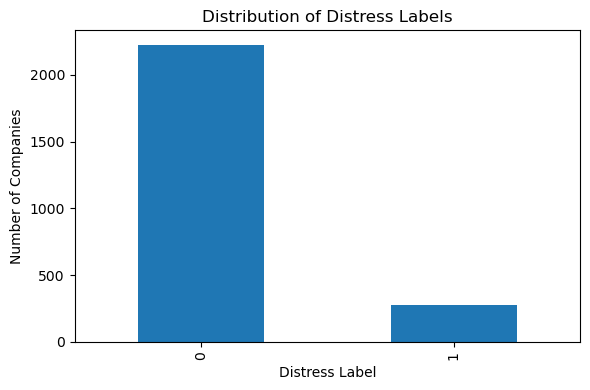

In [175]:
plt.figure(figsize=(6,4))
df["distress_label"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Distress Labels")
plt.xlabel("Distress Label")
plt.ylabel("Number of Companies")
plt.tight_layout()
plt.show()

## EDA Summary by Distress Label

In [176]:
eda_vars = [
    "Return on assets",
    "Return on capital employed",
    "Return on equity",
    "Debt to equity",
    "Interest Coverage Ratio",
    "Current ratio",
    "Quick ratio",
    "Piotroski score",
    "Altman Z Score",
    "CFO_to_PAT",
    "Debt_to_CFO",
    "Debt_to_Assets",
    "CFO_to_Sales",
    "FCF_to_Sales",
    "Sales_Growth",
    "Debtor days",
    "Days Inventory Outstanding",
    "Cash Conversion Cycle",
    "Contingent_Liability_to_Networth",
    "red_flag_score"
]

eda_vars = [v for v in eda_vars if v in df.columns]

group_summary = (
    df.groupby("distress_label")[eda_vars]
    .agg(["mean", "median", "std"])
    .round(2)
)

group_summary

Return on assets               Return on capital employed  \
                           mean median    std                       mean   
distress_label                                                             
0                          8.20   7.11   7.40                      17.29   
1                         -3.19  -1.60  19.68                       0.04   

                             Return on equity                Debt to equity  \
               median    std             mean median     std           mean   
distress_label                                                                
0               14.92  13.58            15.78  12.82   17.12           0.48   
1                2.88  27.11           -24.44   0.14  223.83           6.03   

                ... Days Inventory Outstanding Cash Conversion Cycle         \
                ...                        std                  mean median   
distress_label  ...                                                           
0               ...                   12136.13                -44.94  93.20   
1               ...                    1624.02                246.81  56.57   

                         Contingent_Liability_to_Networth                \
                     std                             mean median    std   
distress_label                                                            
0               12095.53                             0.16   0.03   1.28   
1                1527.53                             5.64   0.11  60.26   

               red_flag_score               
                         mean median   std  
distress_label                              
0                        1.22    0.0  1.65  
1                        4.60    4.0  1.79  

[2 rows x 60 columns]

In [177]:
univariate_vars = [
    "Return on assets", "Return on capital employed", "Debt to equity",
    "Interest Coverage Ratio", "Current ratio", "Quick ratio",
    "Piotroski score", "Altman Z Score", "CFO_to_PAT",
    "Debt_to_CFO", "CFO_to_Sales", "FCF_to_Sales",
    "Debtor days", "Days Inventory Outstanding", "Cash Conversion Cycle"
]

univariate_vars = [v for v in univariate_vars if v in df.columns]

univariate_summary = df[univariate_vars].describe().T.round(2)
univariate_summary

,count,mean,std,min,25%,50%,75%,max
Return on assets,2495.0,6.95,1.018000e+01,-84.66,2.28,6.23,10.86,2.653500e+02
Return on capital employed,2495.0,15.40,1.654000e+01,-297.83,7.50,13.92,21.16,1.370700e+02
Debt to equity,2495.0,1.09,1.150000e+01,0.00,0.08,0.31,0.71,4.398900e+02
Interest Coverage Ratio,2495.0,111.31,2.597710e+03,-230.31,2.21,5.68,17.29,1.266890e+05
Current ratio,2495.0,3.40,3.751000e+01,-16.10,1.28,1.77,2.74,1.860000e+03
Quick ratio,2495.0,2.68,3.545000e+01,-10.26,0.75,1.22,2.08,1.760000e+03
Piotroski score,2495.0,5.29,1.890000e+00,0.00,4.00,5.00,7.00,9.000000e+00
Altman Z Score,2495.0,16.17,5.099700e+02,-101.66,3.18,4.83,7.34,2.547717e+04
CFO_to_PAT,2495.0,4.98,1.309400e+02,-166.25,-0.07,0.86,1.83,6.373360e+03
Debt_to_CFO,2495.0,10127924.51,4.727585e+08,0.00,0.64,2.41,5.98,2.357600e+10


In [178]:
bivariate_summary = (
    df.groupby("distress_label")[univariate_vars]
    .agg(["mean", "median", "std"])
    .round(2)
)

bivariate_summary

Return on assets               Return on capital employed  \
                           mean median    std                       mean   
distress_label                                                             
0                          8.20   7.11   7.40                      17.29   
1                         -3.19  -1.60  19.68                       0.04   

                             Debt to equity                \
               median    std           mean median    std   
distress_label                                              
0               14.92  13.58           0.48   0.27   0.76   
1                2.88  27.11           6.03   0.71  34.37   

               Interest Coverage Ratio  ... FCF_to_Sales Debtor days         \
                                  mean  ...          std        mean median   
distress_label                          ...                                   
0                               125.13  ...         0.28       76.16  63.64   
1                                -1.22  ...         0.90       93.76  47.56   

                       Days Inventory Outstanding                    \
                   std                       mean  median       std   
distress_label                                                        
0                67.72                      -9.47  102.33  12136.13   
1               297.95                     340.15  111.20   1624.02   

               Cash Conversion Cycle                   
                                mean median       std  
distress_label                                         
0                             -44.94  93.20  12095.53  
1                             246.81  56.57   1527.53  

[2 rows x 45 columns]

## Statistical Testing

In [179]:
test_results = []

for var in eda_vars:
    group0 = df[df["distress_label"] == 0][var]
    group1 = df[df["distress_label"] == 1][var]

    t_stat, t_p = ttest_ind(group0, group1, equal_var=False, nan_policy="omit")
    u_stat, u_p = mannwhitneyu(group0, group1, alternative="two-sided")

    test_results.append({
        "Variable": var,
        "Mean_Non_Distressed": group0.mean(),
        "Mean_Distressed": group1.mean(),
        "T_Test_p_Value": t_p,
        "Mann_Whitney_p_Value": u_p
    })

test_results_df = pd.DataFrame(test_results).round(4)

test_results_df

,Variable,Mean_Non_Distressed,Mean_Distressed,T_Test_p_Value,Mann_Whitney_p_Value
0,Return on assets,8.200300e+00,-3.1862,0.0000,0.0000
1,Return on capital employed,1.728580e+01,0.0407,0.0000,0.0000
2,Return on equity,1.577860e+01,-24.4443,0.0033,0.0000
3,Debt to equity,4.833000e-01,6.0277,0.0081,0.0000
4,Interest Coverage Ratio,1.251312e+02,-1.2232,0.0306,0.0000
5,Current ratio,3.665300e+00,1.2277,0.0042,0.0000
6,Quick ratio,2.900900e+00,0.8965,0.0125,0.0000
7,Piotroski score,5.426200e+00,4.2161,0.0000,0.0000
8,Altman Z Score,1.796320e+01,1.5526,0.1528,0.0000
9,CFO_to_PAT,5.017600e+00,4.6864,0.9221,0.9382


<Figure size 600x400 with 0 Axes>

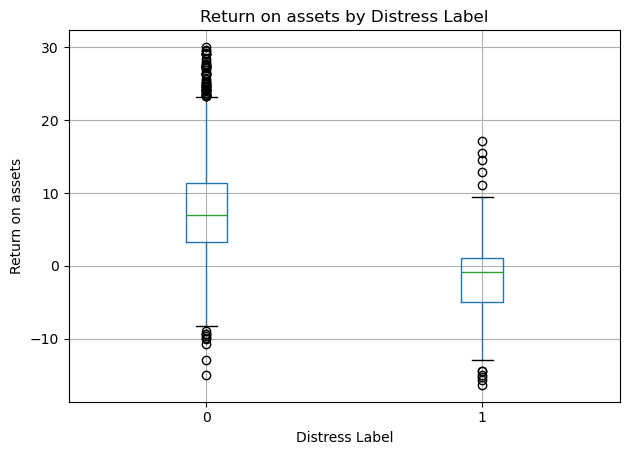

<Figure size 600x400 with 0 Axes>

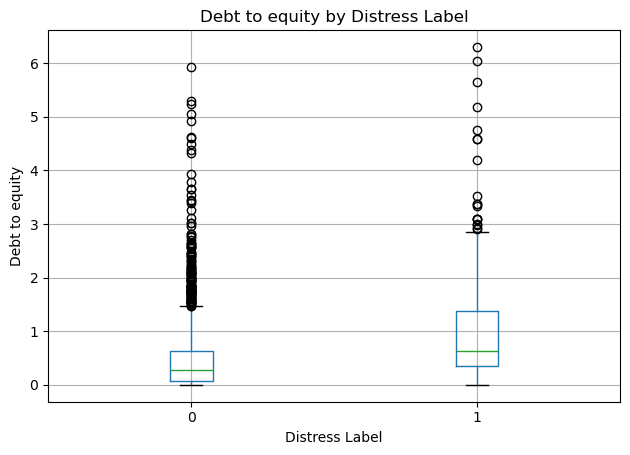

<Figure size 600x400 with 0 Axes>

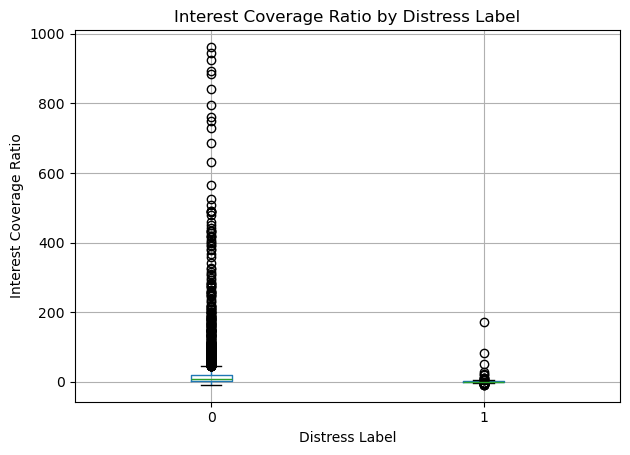

<Figure size 600x400 with 0 Axes>

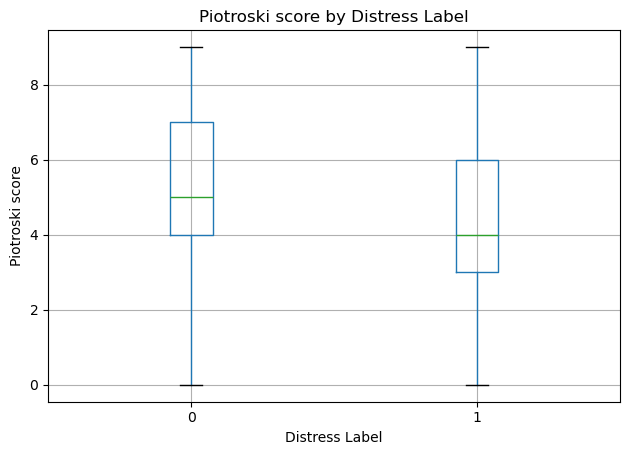

<Figure size 600x400 with 0 Axes>

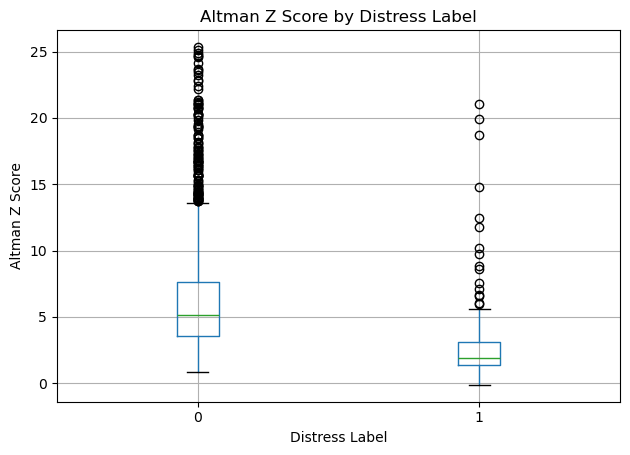

<Figure size 600x400 with 0 Axes>

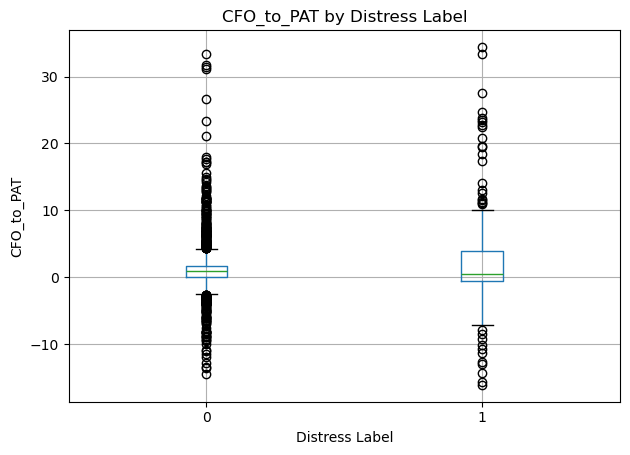

<Figure size 600x400 with 0 Axes>

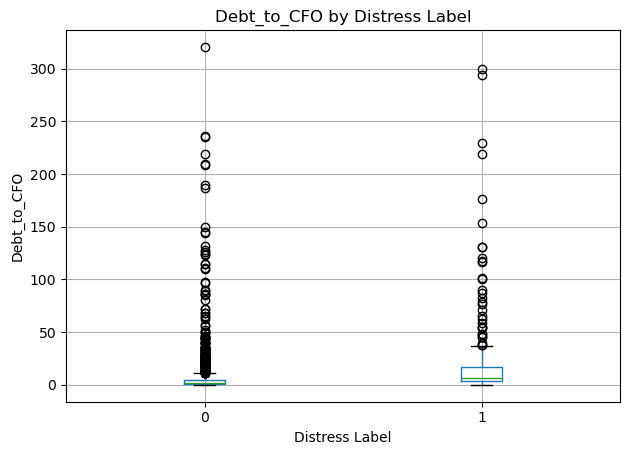

<Figure size 600x400 with 0 Axes>

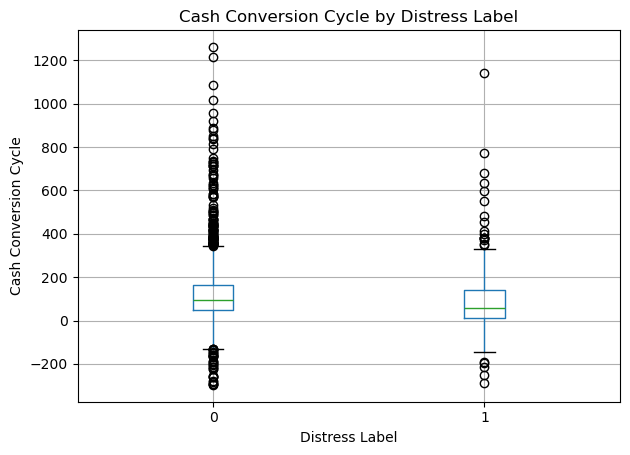

In [180]:
boxplot_vars = [
    "Return on assets",
    "Debt to equity",
    "Interest Coverage Ratio",
    "Piotroski score",
    "Altman Z Score",
    "CFO_to_PAT",
    "Debt_to_CFO",
    "Cash Conversion Cycle"
]

for var in boxplot_vars:
    if var in df.columns:
        low = df[var].quantile(0.01)
        high = df[var].quantile(0.99)
        temp = df[(df[var] >= low) & (df[var] <= high)]

        plt.figure(figsize=(6,4))
        temp.boxplot(column=var, by="distress_label")
        plt.title(f"{var} by Distress Label")
        plt.suptitle("")
        plt.xlabel("Distress Label")
        plt.ylabel(var)
        plt.tight_layout()
        plt.show()

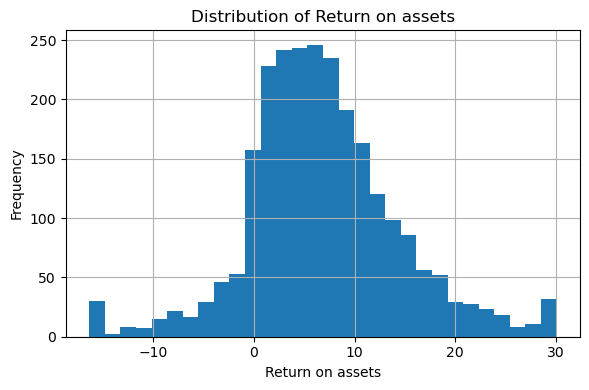

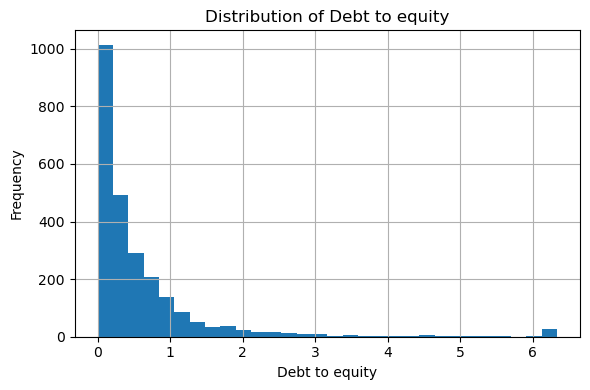

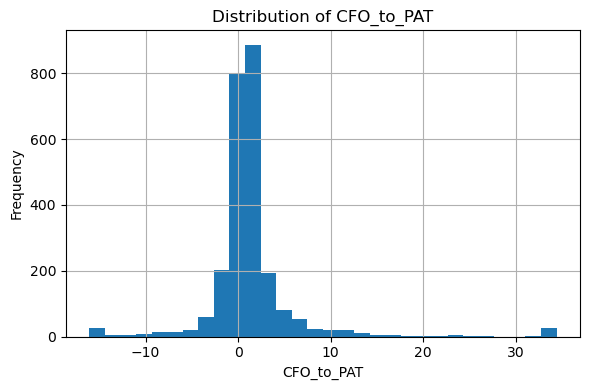

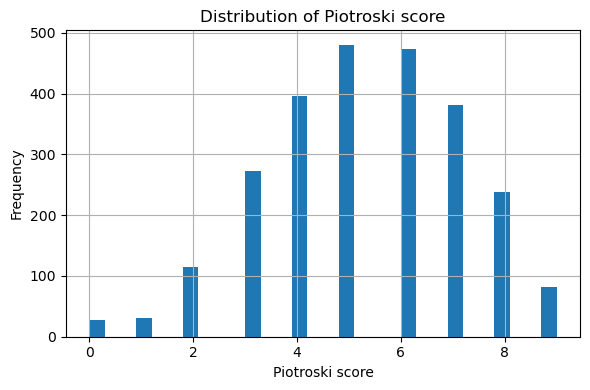

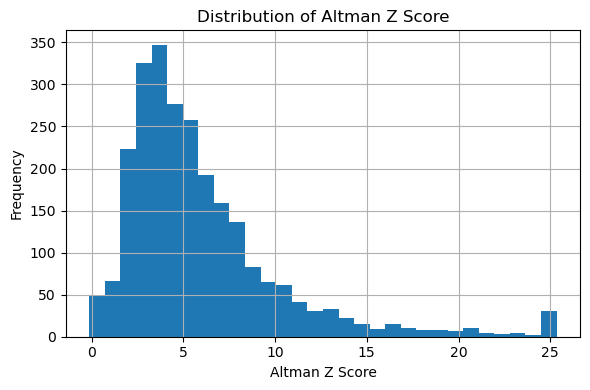

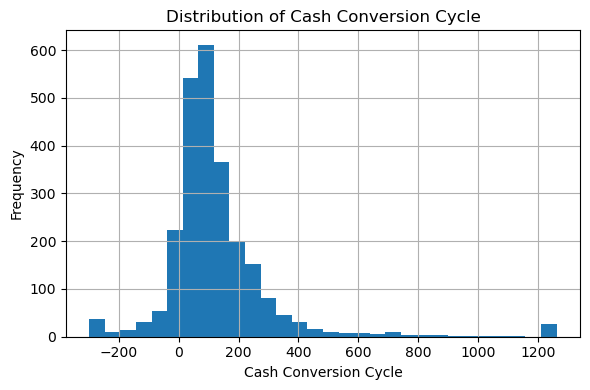

In [181]:
eda_hist_vars = [
    "Return on assets",
    "Debt to equity",
    "CFO_to_PAT",
    "Piotroski score",
    "Altman Z Score",
    "Cash Conversion Cycle"
]

for var in eda_hist_vars:
    
    plt.figure(figsize=(6,4))
    
    temp = df[var].clip(
        lower=df[var].quantile(0.01),
        upper=df[var].quantile(0.99)
    )
    
    temp.hist(bins=30)
    
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

## Correlation Heatmap

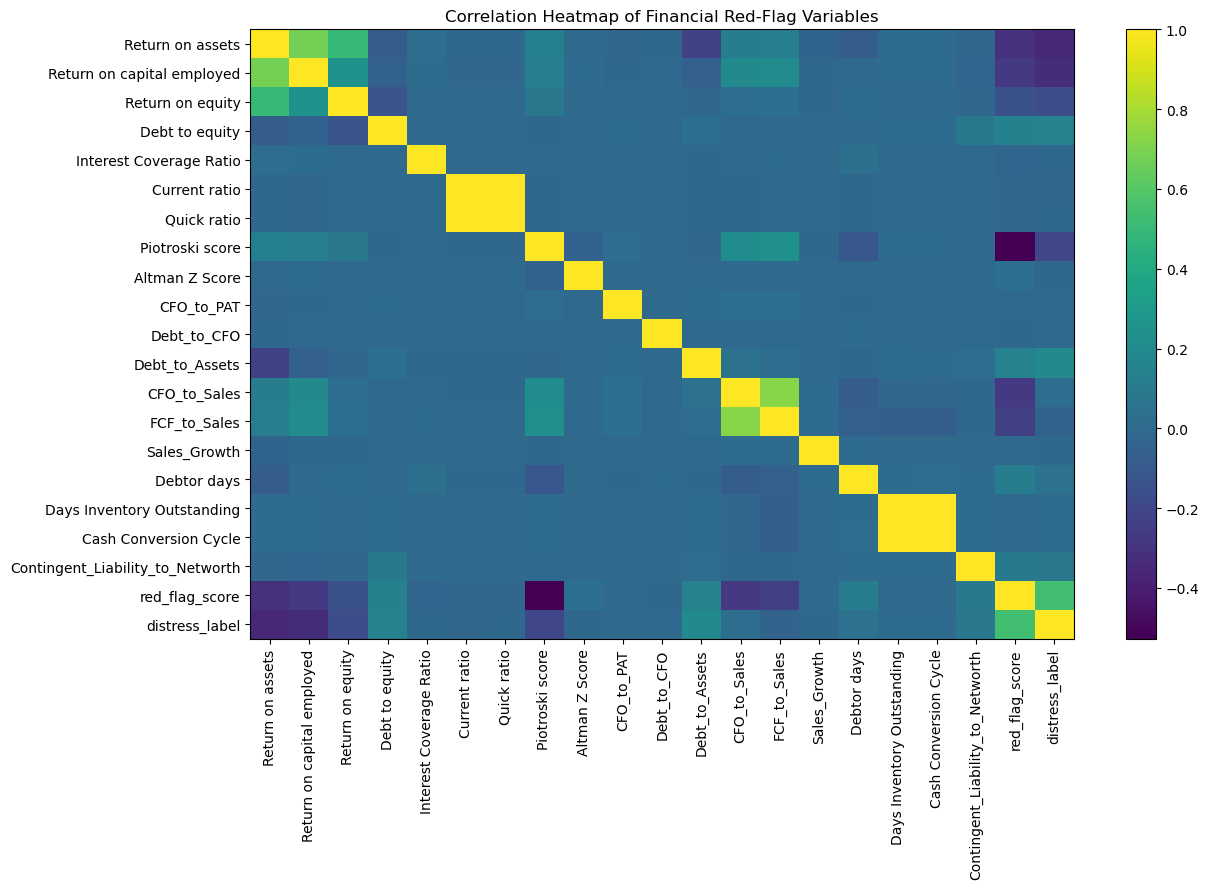

In [182]:
corr_vars = eda_vars + ["distress_label"]

corr = df[corr_vars].corr()

plt.figure(figsize=(13,9))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Heatmap of Financial Red-Flag Variables")
plt.tight_layout()
plt.show()

## Industry Distress Analysis

In [183]:
industry_summary = (
    df.groupby("Industry")["distress_label"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "Total_Companies",
        "sum": "Distressed_Companies",
        "mean": "Distress_Rate"
    })
)

industry_summary["Distress_Rate"] = (
    industry_summary["Distress_Rate"] * 100
).round(2)

industry_summary = industry_summary.sort_values("Distress_Rate", ascending=False)

industry_summary.head(20)

,Total_Companies,Distressed_Companies,Distress_Rate
Industry,,,
Electronic Media,1,1,100.00
Restaurants,12,9,75.00
Other Telecom Services,5,3,60.00
Telecom - Cellular & Fixed line services,7,4,57.14
Airport & Airport services,2,1,50.00
Wellness,2,1,50.00
Jute & Jute Products,4,2,50.00
Dredging,2,1,50.00
Power - Transmission,4,2,50.00


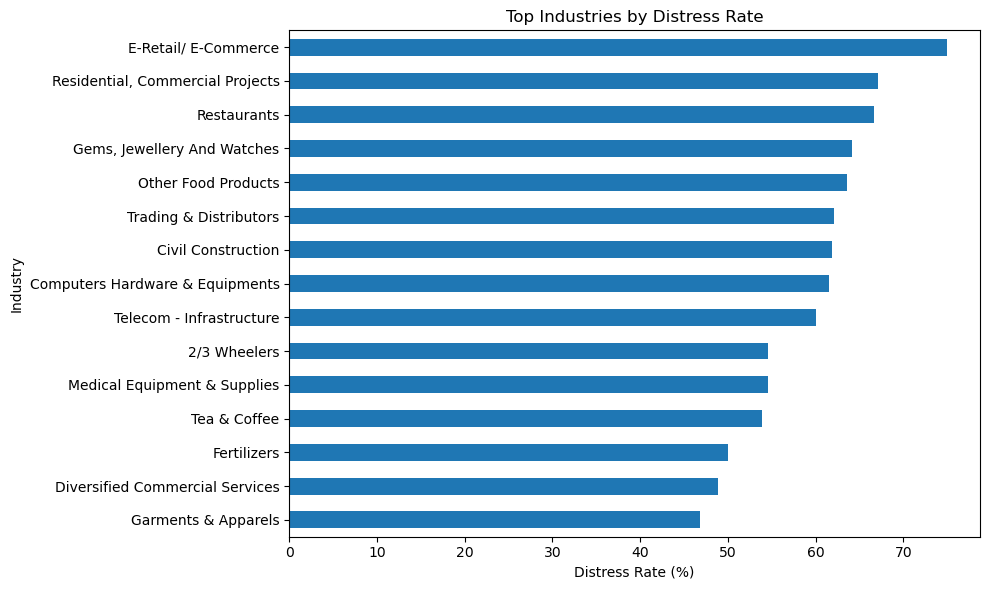

In [102]:
top_industries = industry_summary[industry_summary["Total_Companies"] >= 10].head(15)

plt.figure(figsize=(10,6))
top_industries["Distress_Rate"].sort_values().plot(kind="barh")
plt.title("Top Industries by Distress Rate")
plt.xlabel("Distress Rate (%)")
plt.tight_layout()
plt.show()

In [184]:
audit_risk_summary = pd.DataFrame({
    "Count": df["audit_risk_category"].value_counts(),
    "Percentage": (
        df["audit_risk_category"]
        .value_counts(normalize=True) * 100
    ).round(2)
})

audit_risk_summary

,Count,Percentage
audit_risk_category,,
Low,1547,62.00
High,539,21.60
Medium,409,16.39


## Prepare Modelling Dataset

In [185]:
exclude_cols = [
    "Name",
    "Industry Group",
    "Industry",
    "source_group",
    "risk_category",
    "audit_risk_category",
    "distress_label",
    "red_flag_score",
    "audit_red_flag_score",
    "traditional_distress_score"
]

exclude_cols += flag_cols
exclude_cols += anchor_cols

exclude_cols += [
    "Altman Z Score",
    "Piotroski score",
    "Interest Coverage Ratio",
    "Current ratio"
]

X = df.drop(columns=[c for c in exclude_cols if c in df.columns])
X = X.select_dtypes(include=[np.number])

y = df["distress_label"]

print("X shape:", X.shape)
print(y.value_counts())
print(y.value_counts(normalize=True))

X shape: (2495, 59)
distress_label
0    2222
1     273
Name: count, dtype: int64
distress_label
0    0.890581
1    0.109419
Name: proportion, dtype: float64


## Train Test Split

In [186]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

distress_label
0    0.890607
1    0.109393
Name: proportion, dtype: float64
distress_label
0    0.890521
1    0.109479
Name: proportion, dtype: float64


## Logistics Regression

In [187]:
lr_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("PR-AUC:", average_precision_score(y_test, y_prob_lr))

LOGISTIC REGRESSION
[[578  89]
 [ 16  66]]
              precision    recall  f1-score   support

           0       0.97      0.87      0.92       667
           1       0.43      0.80      0.56        82

    accuracy                           0.86       749
   macro avg       0.70      0.84      0.74       749
weighted avg       0.91      0.86      0.88       749

ROC-AUC: 0.8855815994441802
PR-AUC: 0.614751961031886


## Random Forest

In [188]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))

RANDOM FOREST
[[634  33]
 [ 13  69]]
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       667
           1       0.68      0.84      0.75        82

    accuracy                           0.94       749
   macro avg       0.83      0.90      0.86       749
weighted avg       0.95      0.94      0.94       749

ROC-AUC: 0.9678941017296229
PR-AUC: 0.8074269890839312


## Gradient Boost

In [189]:
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("GRADIENT BOOSTING")
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))
print("PR-AUC:", average_precision_score(y_test, y_prob_gb))

GRADIENT BOOSTING
[[650  17]
 [ 23  59]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       667
           1       0.78      0.72      0.75        82

    accuracy                           0.95       749
   macro avg       0.87      0.85      0.86       749
weighted avg       0.95      0.95      0.95       749

ROC-AUC: 0.9633963506051852
PR-AUC: 0.8161656148370405


## Model Comparison

In [190]:
def model_metrics(name, y_true, y_pred, y_prob):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        "Model": name,
        "Accuracy": report["accuracy"],
        "Distressed_Precision": report["1"]["precision"],
        "Distressed_Recall": report["1"]["recall"],
        "Distressed_F1": report["1"]["f1-score"],
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob)
    }

comparison = pd.DataFrame([
    
    model_metrics("Logistic Regression", y_test, y_pred_lr, y_prob_lr),
    model_metrics("Random Forest", y_test, y_pred_rf, y_prob_rf),
    model_metrics("Gradient Boosting", y_test, y_pred_gb, y_prob_gb)
]).round(3)

comparison

,Model,Accuracy,Distressed_Precision,Distressed_Recall,Distressed_F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.860,0.426,0.805,0.557,0.886,0.615
1,Random Forest,0.939,0.676,0.841,0.750,0.968,0.807
2,Gradient Boosting,0.947,0.776,0.720,0.747,0.963,0.816


## ROC Curve

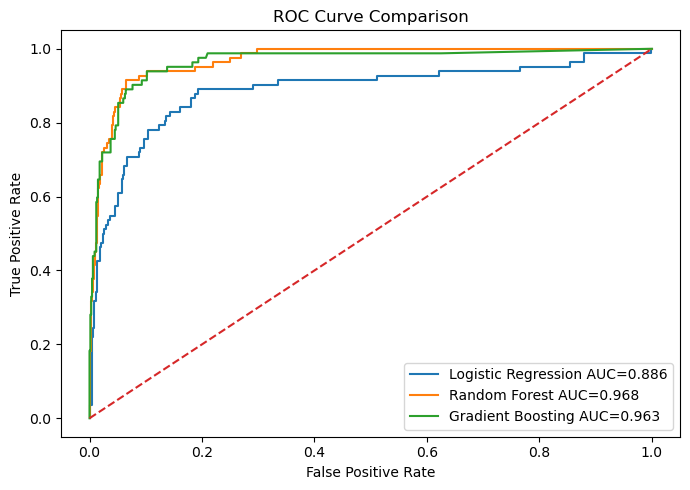

In [191]:
plt.figure(figsize=(7,5))

for name, y_prob in [
    ("Logistic Regression", y_prob_lr),
    ("Random Forest", y_prob_rf),
    ("Gradient Boosting", y_prob_gb)
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## Precision Recall Curve

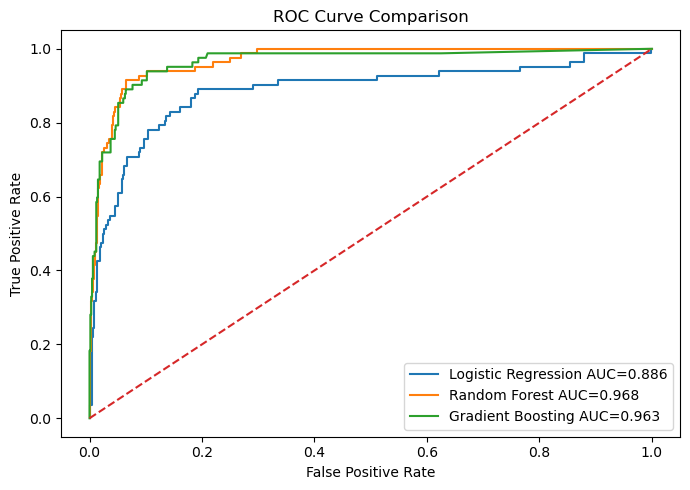

In [192]:
plt.figure(figsize=(7,5))

for name, y_prob in [
    ("Logistic Regression", y_prob_lr),
    ("Random Forest", y_prob_rf),
    ("Gradient Boosting", y_prob_gb)
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## Random Forest feature importance

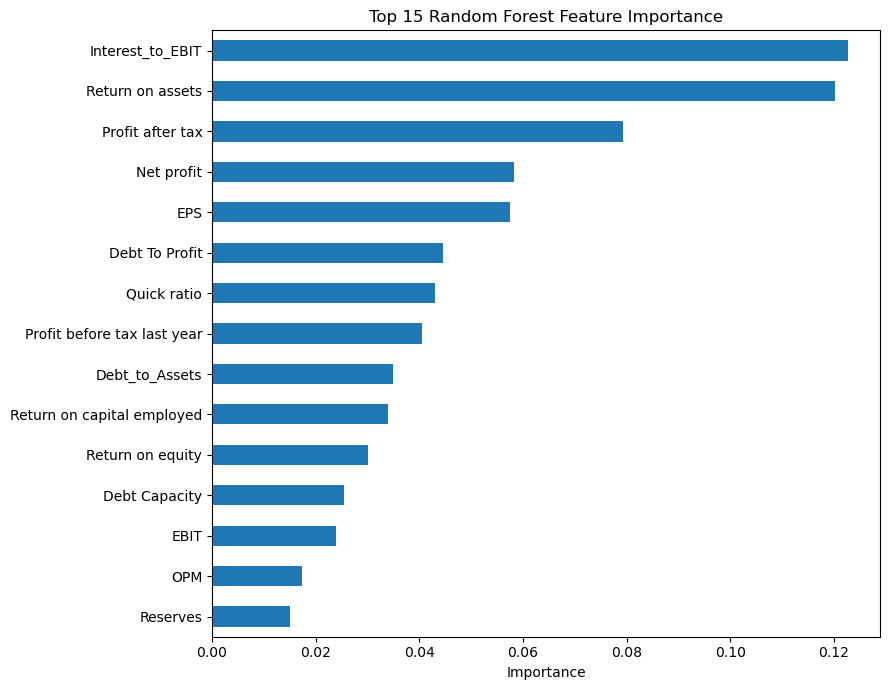

In [193]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)


plt.figure(figsize=(9,7))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Permutation Importance

In [194]:
perm = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance_Mean": perm.importances_mean,
    "Importance_Std": perm.importances_std
}).sort_values("Importance_Mean", ascending=False)

perm_df.head(20)

,Feature,Importance_Mean,Importance_Std
56,Interest_to_EBIT,0.015066,0.002738
11,Total Capital Employed,0.006494,0.000429
14,Quick ratio,0.004820,0.000840
2,Profit after tax,0.003913,0.001759
9,Debt Capacity,0.001596,0.000623
3,Return on assets,0.001337,0.002057
38,EBIT,0.000965,0.000642
52,Debt_to_Assets,0.000889,0.000435
6,EPS,0.000845,0.000821
8,Net worth,0.000830,0.000257


## SHAP Explainability

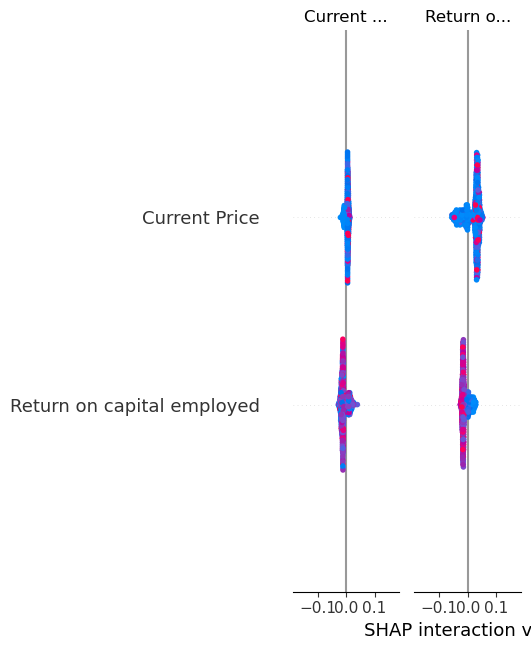

In [195]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

shap.summary_plot(shap_values_class1, X_test, show=False)
plt.tight_layout()
plt.show()

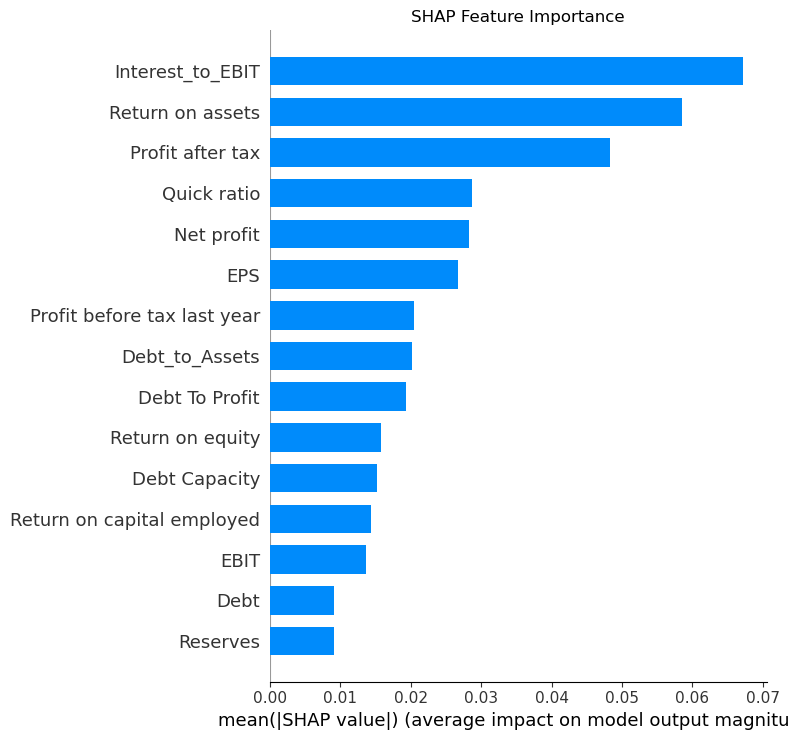

In [201]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Use a smaller sample for clean plotting
X_shap = X_test.copy()

explainer = shap.TreeExplainer(rf_model)

# Old-style SHAP values
shap_values = explainer.shap_values(X_shap)

# For binary classification, take class 1 = distressed
if isinstance(shap_values, list):
    shap_class1 = shap_values[1]
else:
    # Some SHAP versions return 3D array: samples x features x classes
    if len(shap_values.shape) == 3:
        shap_class1 = shap_values[:, :, 1]
    else:
        shap_class1 = shap_values

# 1. SHAP bar plot
shap.summary_plot(
    shap_class1,
    X_shap,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

The SHAP feature importance plot indicates that debt-servicing burden, profitability, liquidity, and leverage-related variables are among the most influential predictors of financial distress. Variables such as Interest_to_EBIT, Return on Assets, Profit after Tax, Quick Ratio, and Debt_to_Assets demonstrated the highest average contribution to model predictions.

The results are financially intuitive and align with financial-distress literature, suggesting that the model captures economically meaningful distress drivers rather than arbitrary statistical patterns.

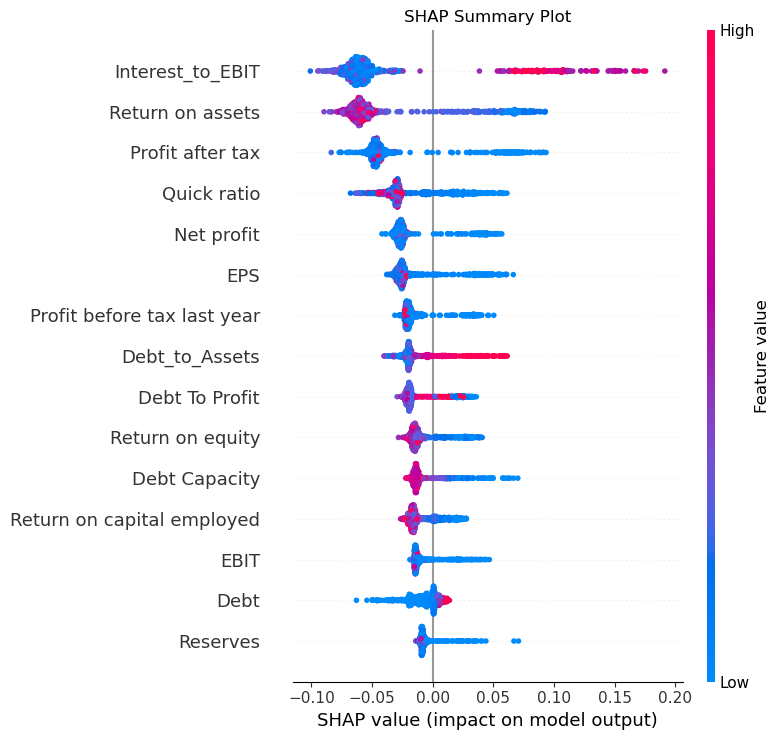

In [202]:
shap.summary_plot(
    shap_class1,
    X_shap,
    max_display=15,
    show=False
)

plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

The SHAP summary plot provides both the magnitude and direction of feature influence on financial distress prediction.

The analysis indicates that:

- Higher Interest_to_EBIT ratios increase predicted distress risk.
- Higher Debt_to_Assets ratios increase predicted distress risk.
- Higher profitability indicators such as Return on Assets and Profit after Tax reduce predicted distress risk.
- Weak liquidity indicators such as lower Quick Ratio increase distress probability.

The SHAP results demonstrate that the model’s behaviour is economically interpretable and aligned with established financial-distress theory.

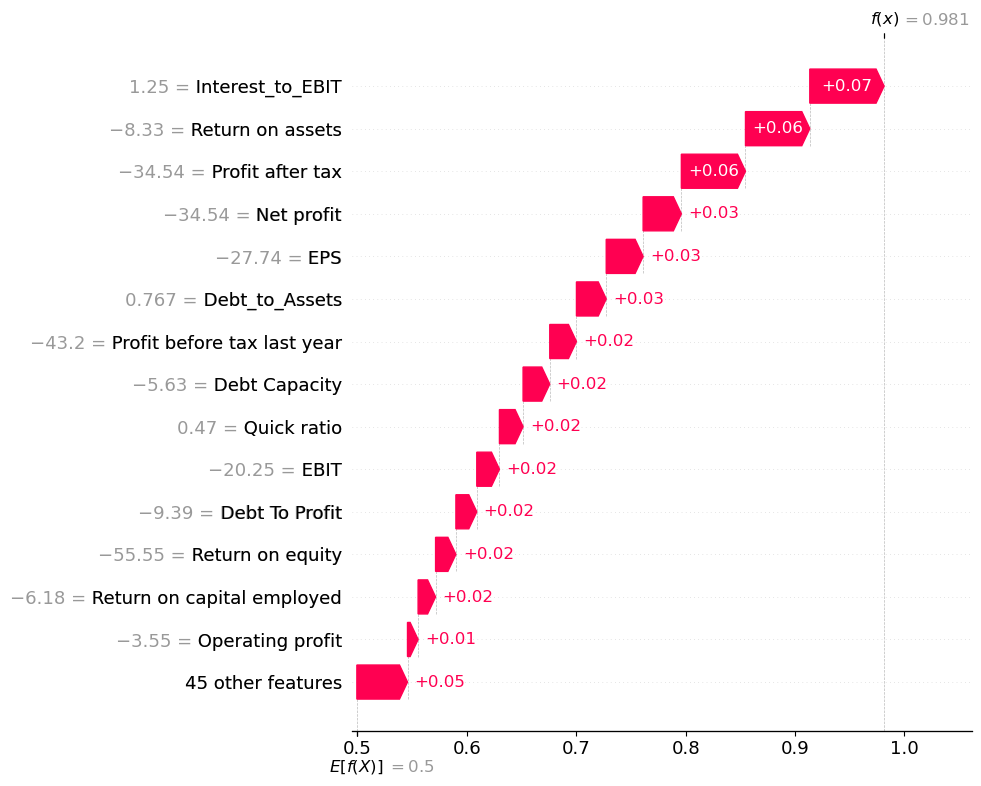

In [204]:
import numpy as np
import shap

# Pick one distressed company from test set
sample_index = y_test[y_test == 1].index[0]
sample_position = list(X_shap.index).index(sample_index)

# Correct base value for class 1
expected_value = explainer.expected_value

if isinstance(expected_value, list):
    base_value = expected_value[1]
elif isinstance(expected_value, np.ndarray):
    base_value = expected_value[1] if expected_value.shape[0] > 1 else expected_value.item()
else:
    base_value = expected_value

# Create single-company explanation
explanation = shap.Explanation(
    values=np.array(shap_class1[sample_position]).reshape(-1),
    base_values=float(base_value),
    data=X_shap.iloc[sample_position].values,
    feature_names=list(X_shap.columns)
)

shap.plots.waterfall(explanation, max_display=15)

The SHAP waterfall plot provides a company-level explanation of distress prediction. For the selected high-risk company, the model assigned a distress probability of approximately 98.1%.

Key contributors increasing predicted distress risk included:

- High interest burden relative to EBIT,
- Negative profitability indicators,
- High leverage,
- Weak liquidity position, and
- Weak debt-servicing capacity.

This demonstrates that the proposed framework provides explainable and interpretable financial-risk assessment rather than functioning as a purely black-box machine learning model.

In [205]:
import shap
import matplotlib.pyplot as plt

# -----------------------------------------
# COMPANY EXPLANATION FUNCTION
# -----------------------------------------

def explain_company(company_name):

    # Find company
    company_row = df[df["Name"].str.contains(company_name, case=False, na=False)]

    if company_row.empty:
        print("Company not found")
        return

    idx = company_row.index[0]

    print("="*80)
    print("COMPANY:", company_row["Name"].values[0])
    print("="*80)

    # Basic Risk Information
    print("\nAUDIT RISK CATEGORY:")
    print(company_row["audit_risk_category"].values[0])

    print("\nAUDIT RED FLAG SCORE:")
    print(company_row["audit_red_flag_score"].values[0])

    print("\nTRADITIONAL DISTRESS LABEL:")
    print(company_row["distress_label"].values[0])

    # ML probability
    if idx in X.index:
        
        prob = rf_model.predict_proba(
            X.loc[[idx]]
        )[0][1]

        print("\nML DISTRESS PROBABILITY:")
        print(round(prob * 100, 2), "%")

    # Risk explanation
    print("\nRULE-BASED RISK EXPLANATION:")
    print(company_row["risk_explanation"].values[0])

    # Active Red Flags
    print("\nACTIVE RED FLAGS:")

    active_flags = []

    for flag in flag_cols:
        if company_row[flag].values[0] == 1:
            active_flags.append(flag)

    if len(active_flags) == 0:
        print("No major red flags")
    else:
        for f in active_flags:
            print("-", f)

    # SHAP Explanation
    print("\nGENERATING SHAP EXPLANATION...")

    explainer = shap.TreeExplainer(rf_model)

    shap_values = explainer.shap_values(X)

    if isinstance(shap_values, list):
        shap_class1 = shap_values[1]
    else:
        if len(shap_values.shape) == 3:
            shap_class1 = shap_values[:, :, 1]
        else:
            shap_class1 = shap_values

    sample_position = list(X.index).index(idx)

    shap_df = pd.DataFrame({
        "Feature": X.columns,
        "SHAP_Value": shap_class1[sample_position],
        "Feature_Value": X.loc[idx].values
    })

    shap_df["Abs_SHAP"] = shap_df["SHAP_Value"].abs()

    shap_df = shap_df.sort_values(
        "Abs_SHAP",
        ascending=False
    ).head(10)

    print("\nTOP SHAP DRIVERS:")
    display(shap_df)

    return shap_df

In [206]:
explain_company("A B Real Estate")

COMPANY: A B Real Estate

AUDIT RISK CATEGORY:
Medium

AUDIT RED FLAG SCORE:
3

TRADITIONAL DISTRESS LABEL:
1

ML DISTRESS PROBABILITY:
91.73 %

RULE-BASED RISK EXPLANATION:
Negative profitability; Weak interest coverage; Weak Altman Z-score

ACTIVE RED FLAGS:
- flag_negative_profit
- flag_low_interest_cover
- flag_low_altman

GENERATING SHAP EXPLANATION...

TOP SHAP DRIVERS:


,Feature,SHAP_Value,Feature_Value,Abs_SHAP
3,Return on assets,0.075183,-1.700000,0.075183
2,Profit after tax,0.069569,-279.990000,0.069569
6,EPS,0.049767,-9.240000,0.049767
39,Net profit,0.043102,-114.820000,0.043102
56,Interest_to_EBIT,-0.037503,0.166035,0.037503
25,Profit before tax last year,0.032930,-253.810000,0.032930
38,EBIT,0.031657,-387.870000,0.031657
16,OPM,0.025190,-91.450000,0.025190
5,Return on equity,0.024630,-7.430000,0.024630
1,Return on capital employed,0.024165,-4.260000,0.024165


,Feature,SHAP_Value,Feature_Value,Abs_SHAP
3,Return on assets,0.075183,-1.700000,0.075183
2,Profit after tax,0.069569,-279.990000,0.069569
6,EPS,0.049767,-9.240000,0.049767
39,Net profit,0.043102,-114.820000,0.043102
56,Interest_to_EBIT,-0.037503,0.166035,0.037503
25,Profit before tax last year,0.032930,-253.810000,0.032930
38,EBIT,0.031657,-387.870000,0.031657
16,OPM,0.025190,-91.450000,0.025190
5,Return on equity,0.024630,-7.430000,0.024630
1,Return on capital employed,0.024165,-4.260000,0.024165


In [207]:
explain_company("Shiva Cement")

COMPANY: Shiva Cement

AUDIT RISK CATEGORY:
High

AUDIT RED FLAG SCORE:
6

TRADITIONAL DISTRESS LABEL:
1

ML DISTRESS PROBABILITY:
99.06 %

RULE-BASED RISK EXPLANATION:
Negative profitability; Negative free cash flow; High debt-to-equity ratio; Weak interest coverage; Weak liquidity position; Weak Altman Z-score; High contingent liabilities relative to net worth

ACTIVE RED FLAGS:
- flag_negative_profit
- flag_high_debt_equity
- flag_low_interest_cover
- flag_low_current_ratio
- flag_low_altman
- flag_high_contingent_liability

GENERATING SHAP EXPLANATION...

TOP SHAP DRIVERS:


,Feature,SHAP_Value,Feature_Value,Abs_SHAP
56,Interest_to_EBIT,0.067961,5.747368,0.067961
3,Return on assets,0.058239,-6.840000,0.058239
2,Profit after tax,0.051852,-123.670000,0.051852
39,Net profit,0.032027,-125.530000,0.032027
6,EPS,0.030625,-4.260000,0.030625
14,Quick ratio,0.029831,0.130000,0.029831
52,Debt_to_Assets,0.029424,0.885268,0.029424
9,Debt Capacity,0.025345,-3.150000,0.025345
25,Profit before tax last year,0.023656,-155.700000,0.023656
29,Reserves,0.022922,-80.950000,0.022922


,Feature,SHAP_Value,Feature_Value,Abs_SHAP
56,Interest_to_EBIT,0.067961,5.747368,0.067961
3,Return on assets,0.058239,-6.840000,0.058239
2,Profit after tax,0.051852,-123.670000,0.051852
39,Net profit,0.032027,-125.530000,0.032027
6,EPS,0.030625,-4.260000,0.030625
14,Quick ratio,0.029831,0.130000,0.029831
52,Debt_to_Assets,0.029424,0.885268,0.029424
9,Debt Capacity,0.025345,-3.150000,0.025345
25,Profit before tax last year,0.023656,-155.700000,0.023656
29,Reserves,0.022922,-80.950000,0.022922


In [208]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def explain_company_in_english(company_name, top_n=10):
    # Search company
    matches = df[df["Name"].str.contains(company_name, case=False, na=False)]

    if matches.empty:
        print("Company not found. Try a shorter or different company name.")
        return

    idx = matches.index[0]
    company = df.loc[idx, "Name"]

    print("=" * 90)
    print(f"COMPANY EXPLANATION: {company}")
    print("=" * 90)

    # Basic risk output
    print("\n1. OVERALL RISK ASSESSMENT")
    print(f"Audit Red-Flag Score: {df.loc[idx, 'audit_red_flag_score']}")
    print(f"Audit Risk Category: {df.loc[idx, 'audit_risk_category']}")
    print(f"Traditional Distress Label: {df.loc[idx, 'distress_label']}")

    if idx in X.index:
        probability = rf_model.predict_proba(X.loc[[idx]])[0][1]
        print(f"ML Distress Probability: {probability * 100:.2f}%")
    else:
        print("Company not available in modelling dataset.")
        return

    # Rule-based English explanation
    print("\n2. RULE-BASED FINANCIAL EXPLANATION")
    if "risk_explanation" in df.columns:
        print(df.loc[idx, "risk_explanation"])
    else:
        print("Risk explanation column not found.")

    # Active red flags
    print("\n3. ACTIVE RED FLAGS")
    active_flags = [flag for flag in flag_cols if df.loc[idx, flag] == 1]

    if active_flags:
        for flag in active_flags:
            print(f"- {flag}")
    else:
        print("No major red flags identified.")

    # SHAP values
    print("\n4. SHAP-BASED MODEL EXPLANATION")

    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X)

    if isinstance(shap_values, list):
        shap_class1 = shap_values[1]
        base_value = explainer.expected_value[1]
    else:
        if len(shap_values.shape) == 3:
            shap_class1 = shap_values[:, :, 1]
            base_value = explainer.expected_value[1]
        else:
            shap_class1 = shap_values
            base_value = explainer.expected_value

    sample_position = list(X.index).index(idx)

    shap_df = pd.DataFrame({
        "Feature": X.columns,
        "Feature_Value": X.loc[idx].values,
        "SHAP_Value": shap_class1[sample_position]
    })

    shap_df["Abs_SHAP"] = shap_df["SHAP_Value"].abs()
    shap_df = shap_df.sort_values("Abs_SHAP", ascending=False).head(top_n)

    display(shap_df)

    # Plain English SHAP interpretation
    print("\n5. PLAIN-ENGLISH SHAP INTERPRETATION")

    for _, row in shap_df.iterrows():
        direction = "increased" if row["SHAP_Value"] > 0 else "reduced"
        print(
            f"- {row['Feature']} = {row['Feature_Value']:.2f} "
            f"{direction} the model's predicted distress risk."
        )

    # SHAP waterfall chart
    print("\n6. SHAP WATERFALL CHART")

    try:
        if isinstance(base_value, np.ndarray):
            base_value = float(np.ravel(base_value)[0])
        else:
            base_value = float(base_value)

        explanation = shap.Explanation(
            values=np.array(shap_class1[sample_position]).reshape(-1),
            base_values=base_value,
            data=X.loc[idx].values,
            feature_names=list(X.columns)
        )

        shap.plots.waterfall(explanation, max_display=top_n)

    except Exception as e:
        print("Waterfall chart could not be generated. Showing bar chart instead.")
        shap_df_plot = shap_df.sort_values("SHAP_Value")

        plt.figure(figsize=(8, 5))
        plt.barh(shap_df_plot["Feature"], shap_df_plot["SHAP_Value"])
        plt.xlabel("SHAP Value")
        plt.title(f"Top SHAP Drivers for {company}")
        plt.tight_layout()
        plt.show()

    return shap_df

COMPANY EXPLANATION: Shiva Cement

1. OVERALL RISK ASSESSMENT
Audit Red-Flag Score: 6
Audit Risk Category: High
Traditional Distress Label: 1
ML Distress Probability: 99.06%

2. RULE-BASED FINANCIAL EXPLANATION
Negative profitability; Negative free cash flow; High debt-to-equity ratio; Weak interest coverage; Weak liquidity position; Weak Altman Z-score; High contingent liabilities relative to net worth

3. ACTIVE RED FLAGS
- flag_negative_profit
- flag_high_debt_equity
- flag_low_interest_cover
- flag_low_current_ratio
- flag_low_altman
- flag_high_contingent_liability

4. SHAP-BASED MODEL EXPLANATION


,Feature,Feature_Value,SHAP_Value,Abs_SHAP
56,Interest_to_EBIT,5.747368,0.067961,0.067961
3,Return on assets,-6.840000,0.058239,0.058239
2,Profit after tax,-123.670000,0.051852,0.051852
39,Net profit,-125.530000,0.032027,0.032027
6,EPS,-4.260000,0.030625,0.030625
14,Quick ratio,0.130000,0.029831,0.029831
52,Debt_to_Assets,0.885268,0.029424,0.029424
9,Debt Capacity,-3.150000,0.025345,0.025345
25,Profit before tax last year,-155.700000,0.023656,0.023656
29,Reserves,-80.950000,0.022922,0.022922



5. PLAIN-ENGLISH SHAP INTERPRETATION
- Interest_to_EBIT = 5.75 increased the model's predicted distress risk.
- Return on assets = -6.84 increased the model's predicted distress risk.
- Profit after tax = -123.67 increased the model's predicted distress risk.
- Net profit = -125.53 increased the model's predicted distress risk.
- EPS = -4.26 increased the model's predicted distress risk.
- Quick ratio = 0.13 increased the model's predicted distress risk.
- Debt_to_Assets = 0.89 increased the model's predicted distress risk.
- Debt Capacity = -3.15 increased the model's predicted distress risk.
- Profit before tax last year = -155.70 increased the model's predicted distress risk.
- Reserves = -80.95 increased the model's predicted distress risk.

6. SHAP WATERFALL CHART


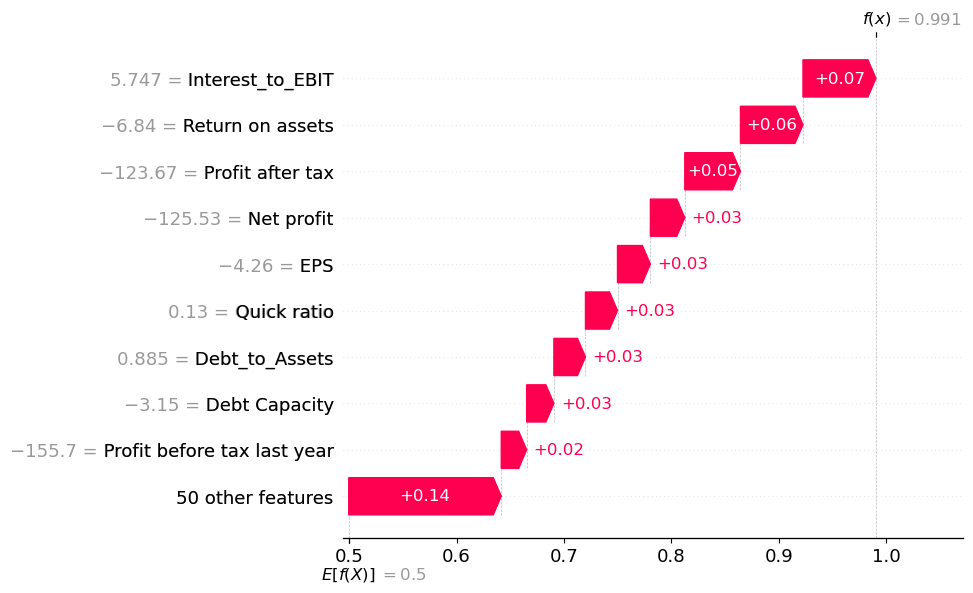

,Feature,Feature_Value,SHAP_Value,Abs_SHAP
56,Interest_to_EBIT,5.747368,0.067961,0.067961
3,Return on assets,-6.840000,0.058239,0.058239
2,Profit after tax,-123.670000,0.051852,0.051852
39,Net profit,-125.530000,0.032027,0.032027
6,EPS,-4.260000,0.030625,0.030625
14,Quick ratio,0.130000,0.029831,0.029831
52,Debt_to_Assets,0.885268,0.029424,0.029424
9,Debt Capacity,-3.150000,0.025345,0.025345
25,Profit before tax last year,-155.700000,0.023656,0.023656
29,Reserves,-80.950000,0.022922,0.022922


In [209]:
explain_company_in_english("Shiva Cement")

## Isolation Forest Anomaly Detection

In [196]:
iso = IsolationForest(
    n_estimators=300,
    contamination=0.10,
    random_state=42
)

df["anomaly_raw"] = iso.fit_predict(X)

df["anomaly_flag"] = np.where(df["anomaly_raw"] == -1, 1, 0)

pd.crosstab(df["distress_label"], df["anomaly_flag"])

anomaly_flag,0,1
distress_label,,
0,2047,175
1,198,75


In [197]:
df["rf_distress_probability"] = rf_model.predict_proba(X)[:, 1]

df["final_risk_score"] = (
    0.60 * df["rf_distress_probability"] * 100 +
    0.25 * (df["red_flag_score"] / df["red_flag_score"].max()) * 100 +
    0.15 * df["anomaly_flag"] * 100
)

df["final_risk_category"] = pd.cut(
    df["final_risk_score"],
    bins=[-1, 35, 65, 100],
    labels=["Low", "Medium", "High"]
)

df[
    ["Name", "Industry", "red_flag_score", "rf_distress_probability",
     "anomaly_flag", "final_risk_score", "final_risk_category"]
].sort_values("final_risk_score", ascending=False).head(25)

,Name,Industry,red_flag_score,rf_distress_probability,anomaly_flag,final_risk_score,final_risk_category
1807,Sh.Renuka Sugar,Sugar,8,0.992389,1,94.543310,High
2800,Indian Acrylics,Petrochemicals,8,0.985804,1,94.148212,High
869,HMT,Industrial Products,8,0.983075,1,93.984525,High
1377,NDTV,TV Broadcasting & Software Production,9,0.932892,1,93.473509,High
3341,Sir Shadi Lal,Sugar,8,0.971491,1,93.289485,High
905,IL&FS Engg.,Civil Construction,8,0.966538,1,92.992298,High
616,Eraaya Lifespace,2/3 Wheelers,8,0.957883,1,92.472963,High
289,BGR Energy Sys.,Civil Construction,8,0.945070,1,91.704209,High
166,Artson,Industrial Products,9,0.900757,1,91.545406,High
2791,IL&FS Transport,Civil Construction,7,0.977173,1,91.130363,High


In [198]:
def explain_company_risk(row):
    reasons = []

    if row.get("Profit after tax", 0) < 0:
        reasons.append("Negative profitability")

    if row.get("Cash from operations last year", 0) < 0:
        reasons.append("Negative operating cash flow")

    if row.get("Free cash flow last year", 0) < 0:
        reasons.append("Negative free cash flow")

    if row.get("Debt to equity", 0) > 2:
        reasons.append("High debt-to-equity ratio")

    if row.get("Interest Coverage Ratio", 999) < 1.5:
        reasons.append("Weak interest coverage")

    if row.get("Current ratio", 999) < 1:
        reasons.append("Weak liquidity position")

    if row.get("Altman Z Score", 999) < 1.8:
        reasons.append("Weak Altman Z-score")

    if row.get("Piotroski score", 9) <= 3:
        reasons.append("Weak Piotroski score")

    if (row.get("Profit after tax", 0) > 0) and (row.get("Cash from operations last year", 0) < 0):
        reasons.append("Profit-cash mismatch")

    if row.get("Contingent_Liability_to_Networth", 0) > 0.25:
        reasons.append("High contingent liabilities relative to net worth")

    if len(reasons) == 0:
        return "No major red flags identified"

    return "; ".join(reasons)


df["risk_explanation"] = df.apply(explain_company_risk, axis=1)

df[
    ["Name", "Industry", "red_flag_score", "risk_category",
     "distress_label", "final_risk_score", "final_risk_category",
     "risk_explanation"]
].sort_values("final_risk_score", ascending=False).head(25)

,Name,Industry,red_flag_score,risk_category,distress_label,final_risk_score,final_risk_category,risk_explanation
1807,Sh.Renuka Sugar,Sugar,8,High,1,94.543310,High,Negative profitability; Negative operating cas...
2800,Indian Acrylics,Petrochemicals,8,High,1,94.148212,High,Negative profitability; Negative operating cas...
869,HMT,Industrial Products,8,High,1,93.984525,High,Negative profitability; Negative operating cas...
1377,NDTV,TV Broadcasting & Software Production,9,High,1,93.473509,High,Negative profitability; Negative operating cas...
3341,Sir Shadi Lal,Sugar,8,High,1,93.289485,High,Negative profitability; Negative operating cas...
905,IL&FS Engg.,Civil Construction,8,High,1,92.992298,High,Negative profitability; Negative operating cas...
616,Eraaya Lifespace,2/3 Wheelers,8,High,1,92.472963,High,Negative profitability; Negative operating cas...
289,BGR Energy Sys.,Civil Construction,8,High,1,91.704209,High,Negative profitability; Negative operating cas...
166,Artson,Industrial Products,9,High,1,91.545406,High,Negative profitability; Negative operating cas...
2791,IL&FS Transport,Civil Construction,7,High,1,91.130363,High,Negative profitability; Negative operating cas...


To improve interpretability, a company-level rule-based explanation was generated alongside the machine learning risk score. This explanation identifies the specific financial red flags responsible for a company being classified as high, medium, or low risk. This makes the model output more useful for audit and governance users, as it does not merely provide a prediction but also explains the financial drivers behind the risk classification.

SHAP analysis was used to understand how individual variables contributed to model predictions. Positive SHAP values increase the predicted probability of distress, while negative SHAP values reduce it. The SHAP summary plot provides a global explanation of the model by ranking variables based on their contribution to distress classification. This supports the explainable AI objective of the study by showing which financial indicators most influence the model’s risk assessment.

ROC-AUC measures the area under the Receiver Operating Characteristic curve, which plots the True Positive Rate against the False Positive Rate at different classification thresholds.

True Positive Rate = TP / (TP + FN)

False Positive Rate = FP / (FP + TN)

ROC-AUC ranges from 0.5 to 1.0, where 0.5 indicates random classification and values closer to 1.0 indicate stronger discriminatory power.

## Multi year data

In [4]:
import pandas as pd
import re
from pathlib import Path

In [5]:
DISTRESSED_DIR = Path(r"C:\Users\Padma T\Documents\DBA\capestone_data\distressed")
HEALTHY_DIR = Path(r"C:\Users\Padma T\Documents\DBA\capestone_data\healthy")

In [6]:
print("Distressed files:")
print(list(DISTRESSED_DIR.glob("*.xlsx")))

print("\nHealthy files:")
print(list(HEALTHY_DIR.glob("*.xlsx")))

Distressed files:
[WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Akar Auto Indust.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Auto.Corp.of Goa.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Autoline Industr.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Automotive Stamp.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Bharat Gears.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Bharat Seats.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Carraro India.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/CLN Energy.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Enkei Wheels.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Federal-Mogul Go.xlsx')]

Healthy files:
[WindowsPath('C:/Users/Padma T/Docum

In [7]:
print("Distressed files:")
print(list(DISTRESSED_DIR.glob("*.xlsx")))

print("\nHealthy files:")
print(list(HEALTHY_DIR.glob("*.xlsx")))

Distressed files:
[WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Akar Auto Indust.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Auto.Corp.of Goa.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Autoline Industr.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Automotive Stamp.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Bharat Gears.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Bharat Seats.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Carraro India.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/CLN Energy.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Enkei Wheels.xlsx'), WindowsPath('C:/Users/Padma T/Documents/DBA/capestone_data/distressed/Federal-Mogul Go.xlsx')]

Healthy files:
[WindowsPath('C:/Users/Padma T/Docum

In [8]:
def extract_section(ds, start_label, end_label=None, prefix=""):

    start = find_row(ds, start_label)

    if start is None:
        return pd.DataFrame()

    if end_label:
        end = find_row(ds, end_label)

        if end is None or end <= start:
            end = len(ds)
    else:
        end = len(ds)

    section = ds.iloc[start+1:end]

    date_rows = section.index[
        section.iloc[:, 0].astype(str).str.strip().eq("Report Date")
    ]

    if len(date_rows) == 0:
        return pd.DataFrame()

    header_row = date_rows[0]

    valid_cols = [
        c for c in range(1, ds.shape[1])
        if pd.notna(ds.iat[header_row, c])
    ]

    records = []

    for r in range(header_row + 1, end):

        metric = ds.iat[r, 0]

        if pd.isna(metric):
            continue

        metric = str(metric).strip()

        if metric.endswith(":"):
            continue

        for c in valid_cols:

            value = ds.iat[r, c]

            if pd.notna(value):

                records.append({
                    "report_date": pd.to_datetime(ds.iat[header_row, c]),
                    "metric": prefix + "_" + clean_name(metric),
                    "value": value
                })

    return pd.DataFrame(records)

In [9]:
def read_screener_file(file_path, status_group):

    print("Reading:", file_path.name)

    ds = pd.read_excel(
        file_path,
        sheet_name="Data Sheet",
        header=None
    )

    company = file_path.stem

    sections = [
        ("pl", "PROFIT & LOSS", "Quarters"),
        ("bs", "BALANCE SHEET", "CASH FLOW:"),
        ("cf", "CASH FLOW:", "PRICE:"),
        ("price", "PRICE:", "DERIVED:"),
        ("derived", "DERIVED:", None),
    ]

    all_parts = []

    for prefix, start, end in sections:

        part = extract_section(ds, start, end, prefix)

        if not part.empty:
            all_parts.append(part)

    if len(all_parts) == 0:
        print("No sections extracted for:", file_path.name)
        return pd.DataFrame()

    long_df = pd.concat(all_parts, ignore_index=True)

    wide_df = (
        long_df
        .pivot_table(
            index="report_date",
            columns="metric",
            values="value",
            aggfunc="first"
        )
        .reset_index()
    )

    wide_df.insert(0, "company", company)
    wide_df["status_group"] = status_group
    wide_df["source_file"] = file_path.name
    wide_df["fy"] = wide_df["report_date"].dt.year

    return wide_df

In [10]:
all_company_dfs = []

# DISTRESSED
for file in DISTRESSED_DIR.glob("*.xlsx"):

    try:
        df = read_screener_file(file, "distressed")

        if not df.empty:
            all_company_dfs.append(df)

    except Exception as e:
        print("ERROR:", file.name)
        print(e)

# HEALTHY
for file in HEALTHY_DIR.glob("*.xlsx"):

    try:
        df = read_screener_file(file, "healthy")

        if not df.empty:
            all_company_dfs.append(df)

    except Exception as e:
        print("ERROR:", file.name)
        print(e)

print("\nTotal company dfs:", len(all_company_dfs))

Reading: Akar Auto Indust.xlsx
Reading: Auto.Corp.of Goa.xlsx
Reading: Autoline Industr.xlsx
Reading: Automotive Stamp.xlsx
Reading: Bharat Gears.xlsx
Reading: Bharat Seats.xlsx
Reading: Carraro India.xlsx
Reading: CLN Energy.xlsx
Reading: Enkei Wheels.xlsx
Reading: Federal-Mogul Go.xlsx
Reading: Fiem Industries.xlsx
Reading: Frontier Springs.xlsx
Reading: G S Auto Intl.xlsx
Reading: Him Teknoforg.xlsx
Reading: Hind.Composites.xlsx
Reading: Indag Rubber.xlsx
Reading: India Nipp.Elec.xlsx
Reading: Menon Bearings.xlsx
Reading: MRF.xlsx
Reading: Saint-Gob. Sekur.xlsx

Total company dfs: 20


In [11]:
master = pd.concat(
    all_company_dfs,
    ignore_index=True,
    sort=False
)

print(master.shape)

master.head()

(185, 39)


metric,company,report_date,bs_borrowings,bs_capital_work_in_progress,bs_cash_bank,bs_equity_share_capital,bs_face_value,bs_inventory,bs_investments,bs_net_block,...,pl_power_and_fuel,pl_profit_before_tax,pl_raw_material_cost,pl_sales,pl_selling_and_admin,pl_tax,status_group,source_file,fy,bs_new_bonus_shares
0,Akar Auto Indust,2016-03-31,44.80,0.84,1.35,5.39,10.0,48.97,0.11,29.52,...,13.95,2.83,120.57,183.59,8.29,1.01,distressed,Akar Auto Indust.xlsx,2016,NaN
1,Akar Auto Indust,2017-03-31,51.06,2.52,1.54,5.39,10.0,48.34,0.08,34.98,...,14.36,3.86,118.11,188.67,8.82,1.41,distressed,Akar Auto Indust.xlsx,2017,NaN
2,Akar Auto Indust,2018-03-31,57.01,1.16,1.20,5.39,5.0,53.80,0.08,37.23,...,16.77,4.97,161.46,241.00,8.96,1.77,distressed,Akar Auto Indust.xlsx,2018,NaN
3,Akar Auto Indust,2019-03-31,66.35,4.11,1.88,5.39,5.0,61.47,0.06,38.77,...,21.69,5.91,189.40,276.58,9.98,0.70,distressed,Akar Auto Indust.xlsx,2019,NaN
4,Akar Auto Indust,2020-03-31,66.20,NaN,2.64,5.39,5.0,59.46,0.06,43.38,...,16.70,-2.49,118.11,197.63,9.13,0.57,distressed,Akar Auto Indust.xlsx,2020,NaN


In [12]:
master.to_csv(
    r"C:\Users\Padma T\Documents\DBA\master_multiyear_dataset.csv",
    index=False
)

print("Master dataset saved.")

Master dataset saved.


In [13]:
master.columns.tolist()

['company',
 'report_date',
 'bs_borrowings',
 'bs_capital_work_in_progress',
 'bs_cash_bank',
 'bs_equity_share_capital',
 'bs_face_value',
 'bs_inventory',
 'bs_investments',
 'bs_net_block',
 'bs_no_of_equity_shares',
 'bs_other_assets',
 'bs_other_liabilities',
 'bs_receivables',
 'bs_reserves',
 'bs_total',
 'cf_cash_from_financing_activity',
 'cf_cash_from_investing_activity',
 'cf_cash_from_operating_activity',
 'cf_net_cash_flow',
 'pl_change_in_inventory',
 'pl_depreciation',
 'pl_dividend_amount',
 'pl_employee_cost',
 'pl_interest',
 'pl_net_profit',
 'pl_other_expenses',
 'pl_other_income',
 'pl_other_mfr_exp',
 'pl_power_and_fuel',
 'pl_profit_before_tax',
 'pl_raw_material_cost',
 'pl_sales',
 'pl_selling_and_admin',
 'pl_tax',
 'status_group',
 'source_file',
 'fy',
 'bs_new_bonus_shares']

In [14]:
def safe_div(a, b):
    return a / b.replace(0, pd.NA)

numeric_cols = master.columns.drop([
    "company",
    "status_group",
    "source_file",
    "report_date"
])

for col in numeric_cols:
    master[col] = pd.to_numeric(master[col], errors="coerce")

master = master.sort_values([
    "company",
    "report_date"
])

master["equity_total"] = (
    master["bs_equity_share_capital"].fillna(0)
    + master["bs_reserves"].fillna(0)
)

master["debt_to_equity"] = safe_div(
    master["bs_borrowings"],
    master["equity_total"]
)

master["pat_margin"] = safe_div(
    master["pl_net_profit"],
    master["pl_sales"]
)

master["sales_growth_yoy"] = (
    master.groupby("company")["pl_sales"].pct_change()
)

master["pat_growth_yoy"] = (
    master.groupby("company")["pl_net_profit"].pct_change()
)

In [15]:
master["distress_current_year"] = (
    (master["pl_net_profit"] < 0)
    | (master["debt_to_equity"] > 2.5)
).astype(int)

master["distress_next_year"] = (
    master.groupby("company")["distress_current_year"].shift(-1)
)

In [16]:
master["company"].nunique()

20

In [17]:
master.groupby("company")["fy"].nunique().sort_values()

company
CLN Energy           4
Carraro India        6
Menon Bearings       7
Indag Rubber         8
Enkei Wheels         9
Automotive Stamp    10
Akar Auto Indust    10
Autoline Industr    10
Bharat Gears        10
Bharat Seats        10
Fiem Industries     10
Federal-Mogul Go    10
Frontier Springs    10
G S Auto Intl       10
Him Teknoforg       10
Auto.Corp.of Goa    10
Hind.Composites     10
India Nipp.Elec     10
MRF                 10
Saint-Gob. Sekur    10
Name: fy, dtype: int64

In [18]:
master["status_group"].value_counts()

status_group
healthy       95
distressed    90
Name: count, dtype: int64

In [20]:
missing = master.isnull().mean().sort_values(ascending=False)

missing.head(30)

metric
bs_new_bonus_shares                0.994595
pl_dividend_amount                 0.427027
bs_investments                     0.308108
bs_capital_work_in_progress        0.118919
distress_next_year                 0.108108
sales_growth_yoy                   0.108108
pat_growth_yoy                     0.108108
pl_tax                             0.059459
bs_borrowings                      0.054054
debt_to_equity                     0.054054
pl_other_mfr_exp                   0.043243
bs_no_of_equity_shares             0.043243
pl_selling_and_admin               0.043243
pl_power_and_fuel                  0.037838
pl_other_expenses                  0.016216
cf_cash_from_financing_activity    0.010811
cf_net_cash_flow                   0.005405
bs_other_liabilities               0.000000
bs_receivables                     0.000000
bs_inventory                       0.000000
bs_cash_bank                       0.000000
bs_equity_share_capital            0.000000
company                  

In [21]:
features = [

    "company",
    "fy",
    "status_group",

    "pl_sales",
    "pl_net_profit",

    "bs_borrowings",

    "cf_cash_from_operating_activity",

    "debt_to_equity",
    "pat_margin",

    "sales_growth_yoy",
    "pat_growth_yoy",

    "distress_next_year"
]

model_df = master[features].copy()

In [22]:
model_df = model_df.dropna(
    subset=[
        "pl_sales",
        "pl_net_profit",
        "debt_to_equity",
        "distress_next_year"
    ]
)

print(model_df.shape)

(155, 12)


In [23]:
single_year_features = [

    "pl_sales",
    "pl_net_profit",
    "debt_to_equity",
    "pat_margin"
]

single_df = model_df.dropna(
    subset=single_year_features + ["distress_next_year"]
)

In [24]:
multi_year_features = [

    "pl_sales",
    "pl_net_profit",
    "debt_to_equity",
    "pat_margin",

    "sales_growth_yoy",
    "pat_growth_yoy"
]

multi_df = model_df.dropna(
    subset=multi_year_features + ["distress_next_year"]
)

In [25]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [26]:
X1 = single_df[single_year_features]

y1 = single_df["distress_next_year"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.3,
    random_state=42
)

scaler1 = StandardScaler()

X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

lr1 = LogisticRegression()

lr1.fit(X1_train_scaled, y1_train)

pred1 = lr1.predict(X1_test_scaled)

prob1 = lr1.predict_proba(X1_test_scaled)[:,1]

In [27]:
print("SINGLE YEAR MODEL")

print("Accuracy:", accuracy_score(y1_test, pred1))
print("Precision:", precision_score(y1_test, pred1))
print("Recall:", recall_score(y1_test, pred1))
print("F1:", f1_score(y1_test, pred1))
print("ROC AUC:", roc_auc_score(y1_test, prob1))

SINGLE YEAR MODEL
Accuracy: 0.8297872340425532
Precision: 0.5
Recall: 0.25
F1: 0.3333333333333333
ROC AUC: 0.9102564102564102


In [28]:
X2 = multi_df[multi_year_features]

y2 = multi_df["distress_next_year"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.3,
    random_state=42
)

scaler2 = StandardScaler()

X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

lr2 = LogisticRegression()

lr2.fit(X2_train_scaled, y2_train)

pred2 = lr2.predict(X2_test_scaled)

prob2 = lr2.predict_proba(X2_test_scaled)[:,1]

In [29]:
print("MULTI YEAR MODEL")

print("Accuracy:", accuracy_score(y2_test, pred2))
print("Precision:", precision_score(y2_test, pred2))
print("Recall:", recall_score(y2_test, pred2))
print("F1:", f1_score(y2_test, pred2))
print("ROC AUC:", roc_auc_score(y2_test, prob2))

MULTI YEAR MODEL
Accuracy: 0.8333333333333334
Precision: 0.25
Recall: 0.2
F1: 0.2222222222222222
ROC AUC: 0.8702702702702703


In [30]:
comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC"
    ],

    "Single_Year_Model": [

        accuracy_score(y1_test, pred1),
        precision_score(y1_test, pred1),
        recall_score(y1_test, pred1),
        f1_score(y1_test, pred1),
        roc_auc_score(y1_test, prob1)
    ],

    "Multi_Year_Model": [

        accuracy_score(y2_test, pred2),
        precision_score(y2_test, pred2),
        recall_score(y2_test, pred2),
        f1_score(y2_test, pred2),
        roc_auc_score(y2_test, prob2)
    ]
})

comparison

,Metric,Single_Year_Model,Multi_Year_Model
0,Accuracy,0.829787,0.833333
1,Precision,0.500000,0.250000
2,Recall,0.250000,0.200000
3,F1,0.333333,0.222222
4,ROC AUC,0.910256,0.870270


In [31]:
import numpy as np
import pandas as pd

def col_exists(df, col):
    return col in df.columns

def safe_div(a, b):
    return a / b.replace(0, np.nan)

def add_if_exists(df, new_col, numerator, denominator):
    if numerator in df.columns and denominator in df.columns:
        df[new_col] = safe_div(df[numerator], df[denominator])
    else:
        df[new_col] = np.nan

def yoy(df, col):
    if col in df.columns:
        return df.groupby("company")[col].pct_change()
    else:
        return np.nan

def three_year_change(df, col):
    if col in df.columns:
        return df.groupby("company")[col].pct_change(periods=3)
    else:
        return np.nan

In [33]:
non_numeric_cols = ["company", "status_group", "source_file", "report_date"]

for col in master.columns:
    if col not in non_numeric_cols:
        master[col] = pd.to_numeric(master[col], errors="coerce")

master = master.sort_values(["company", "fy"])

In [34]:
# Equity / Net worth
if "bs_equity_share_capital" in master.columns and "bs_reserves" in master.columns:
    master["net_worth"] = (
        master["bs_equity_share_capital"].fillna(0)
        + master["bs_reserves"].fillna(0)
    )
else:
    master["net_worth"] = np.nan

# Debt to Equity
add_if_exists(master, "debt_to_equity", "bs_borrowings", "net_worth")

# PAT Margin
add_if_exists(master, "pat_margin", "pl_net_profit", "pl_sales")

# CFO to Sales
add_if_exists(master, "cfo_to_sales", "cf_cash_from_operating_activity", "pl_sales")

# CFO to Debt
add_if_exists(master, "cfo_to_debt", "cf_cash_from_operating_activity", "bs_borrowings")

# CFO to PAT - earnings quality
add_if_exists(master, "cfo_to_pat", "cf_cash_from_operating_activity", "pl_net_profit")

# Asset turnover
add_if_exists(master, "asset_turnover", "pl_sales", "bs_total_assets")

# ROA
add_if_exists(master, "roa", "pl_net_profit", "bs_total_assets")

# ROE
add_if_exists(master, "roe", "pl_net_profit", "net_worth")

In [36]:
if "pl_profit_before_tax" in master.columns and "pl_interest" in master.columns:
    master["ebit_approx"] = master["pl_profit_before_tax"] + master["pl_interest"]
    master["interest_coverage"] = safe_div(master["ebit_approx"], master["pl_interest"])
else:
    master["interest_coverage"] = np.nan

In [37]:
# Total cost to sales
if "pl_expenses" in master.columns and "pl_sales" in master.columns:
    master["cost_to_sales"] = safe_div(master["pl_expenses"], master["pl_sales"])
else:
    master["cost_to_sales"] = np.nan

# Raw material cost to sales, if available
possible_raw_material_cols = [
    "pl_raw_material_cost",
    "pl_cost_of_materials_consumed",
    "pl_material_cost"
]

raw_col = next((c for c in possible_raw_material_cols if c in master.columns), None)

if raw_col:
    master["raw_material_to_sales"] = safe_div(master[raw_col], master["pl_sales"])
else:
    master["raw_material_to_sales"] = np.nan

In [38]:
# Capex approximation from fixed assets movement
possible_fixed_asset_cols = [
    "bs_fixed_assets",
    "bs_net_block",
    "bs_gross_block"
]

fixed_asset_col = next((c for c in possible_fixed_asset_cols if c in master.columns), None)

if fixed_asset_col:
    master["fixed_assets"] = master[fixed_asset_col]
    master["capex_approx"] = master.groupby("company")["fixed_assets"].diff()
else:
    master["fixed_assets"] = np.nan
    master["capex_approx"] = np.nan

# Capex intensity
master["capex_to_cfo"] = safe_div(
    master["capex_approx"],
    master["cf_cash_from_operating_activity"]
) if "cf_cash_from_operating_activity" in master.columns else np.nan

master["capex_to_sales"] = safe_div(
    master["capex_approx"],
    master["pl_sales"]
) if "pl_sales" in master.columns else np.nan

In [39]:
# Receivables to sales
add_if_exists(master, "receivables_to_sales", "bs_trade_receivables", "pl_sales")

# Inventory to sales
add_if_exists(master, "inventory_to_sales", "bs_inventories", "pl_sales")

# Payables to sales
add_if_exists(master, "payables_to_sales", "bs_trade_payables", "pl_sales")

# Working capital approximation
if "bs_current_assets" in master.columns and "bs_current_liabilities" in master.columns:
    master["working_capital"] = master["bs_current_assets"] - master["bs_current_liabilities"]
    master["working_capital_to_sales"] = safe_div(master["working_capital"], master["pl_sales"])
else:
    master["working_capital"] = np.nan
    master["working_capital_to_sales"] = np.nan

In [40]:
possible_contingent_cols = [
    "bs_contingent_liabilities",
    "derived_contingent_liabilities",
    "pl_contingent_liabilities"
]

cont_col = next((c for c in possible_contingent_cols if c in master.columns), None)

if cont_col:
    master["contingent_liability"] = master[cont_col]
    master["contingent_liability_to_networth"] = safe_div(
        master["contingent_liability"],
        master["net_worth"]
    )
else:
    master["contingent_liability"] = np.nan
    master["contingent_liability_to_networth"] = np.nan

In [41]:
trend_base_cols = [
    "pl_sales",
    "pl_net_profit",
    "bs_borrowings",
    "cf_cash_from_operating_activity",
    "net_worth",
    "fixed_assets",
    "capex_approx",
    "cost_to_sales",
    "raw_material_to_sales",
    "pat_margin",
    "cfo_to_sales",
    "cfo_to_pat",
    "interest_coverage",
    "debt_to_equity",
    "receivables_to_sales",
    "inventory_to_sales",
    "payables_to_sales",
    "contingent_liability",
    "contingent_liability_to_networth"
]

for col in trend_base_cols:
    if col in master.columns:
        master[col + "_yoy"] = yoy(master, col)
        master[col + "_3yr_change"] = three_year_change(master, col)

C:\Users\Padma T\AppData\Local\Temp\ipykernel_32932\2943946012.py:18: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  return df.groupby("company")[col].pct_change()
C:\Users\Padma T\AppData\Local\Temp\ipykernel_32932\2943946012.py:24: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  return df.groupby("company")[col].pct_change(periods=3)
C:\Users\Padma T\AppData\Local\Temp\ipykernel_32932\2943946012.py:18: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to

In [42]:
# 1. Debt growing faster than sales
master["debt_sales_growth_gap"] = (
    master["bs_borrowings_yoy"] - master["pl_sales_yoy"]
)

# 2. Cost rising while sales falling
master["cost_sales_pressure"] = (
    master["cost_to_sales_yoy"] - master["pl_sales_yoy"]
)

# 3. PAT falling faster than sales
master["profit_sales_divergence"] = (
    master["pl_net_profit_yoy"] - master["pl_sales_yoy"]
)

# 4. CFO deterioration versus profit deterioration
master["cfo_profit_gap"] = (
    master["cf_cash_from_operating_activity_yoy"] - master["pl_net_profit_yoy"]
)

# 5. Capex increasing while CFO falling
master["capex_cfo_stress"] = (
    master["capex_approx_yoy"] - master["cf_cash_from_operating_activity_yoy"]
)

# 6. Fixed assets growing faster than sales - failed expansion signal
master["asset_sales_growth_gap"] = (
    master["fixed_assets_yoy"] - master["pl_sales_yoy"]
)

# 7. Receivables growing faster than sales
master["receivable_sales_stress"] = (
    master["receivables_to_sales_yoy"] - master["pl_sales_yoy"]
)

# 8. Inventory growing faster than sales
master["inventory_sales_stress"] = (
    master["inventory_to_sales_yoy"] - master["pl_sales_yoy"]
)

# 9. Contingent liability build-up
master["contingent_liability_stress"] = (
    master["contingent_liability_to_networth_yoy"]
)

# 10. Interest coverage deterioration
master["interest_coverage_stress"] = (
    -1 * master["interest_coverage_yoy"]
)

In [43]:
master["flag_negative_pat"] = (master["pl_net_profit"] < 0).astype(int)

master["flag_negative_cfo"] = (
    master["cf_cash_from_operating_activity"] < 0
).astype(int)

master["flag_high_debt_equity"] = (
    master["debt_to_equity"] > 2.5
).astype(int)

master["flag_low_interest_coverage"] = (
    master["interest_coverage"] < 1
).astype(int)

master["flag_sales_decline"] = (
    master["pl_sales_yoy"] < 0
).astype(int)

master["flag_cost_pressure"] = (
    master["cost_sales_pressure"] > 0
).astype(int)

master["flag_debt_growing_faster_than_sales"] = (
    master["debt_sales_growth_gap"] > 0
).astype(int)

master["flag_capex_with_cfo_decline"] = (
    (master["capex_approx_yoy"] > 0) &
    (master["cf_cash_from_operating_activity_yoy"] < 0)
).astype(int)

master["flag_pat_positive_cfo_negative"] = (
    (master["pl_net_profit"] > 0) &
    (master["cf_cash_from_operating_activity"] < 0)
).astype(int)

master["flag_margin_compression"] = (
    master["pat_margin_yoy"] < 0
).astype(int)

In [44]:
red_flags = [
    "flag_negative_pat",
    "flag_negative_cfo",
    "flag_high_debt_equity",
    "flag_low_interest_coverage",
    "flag_sales_decline",
    "flag_cost_pressure",
    "flag_debt_growing_faster_than_sales",
    "flag_capex_with_cfo_decline",
    "flag_pat_positive_cfo_negative",
    "flag_margin_compression"
]

master["distress_signal_score"] = master[red_flags].sum(axis=1)

In [45]:
master["distress_current_year"] = (
    (master["flag_negative_pat"] == 1)
    | (master["flag_negative_cfo"] == 1)
    | (master["flag_low_interest_coverage"] == 1)
    | (master["flag_high_debt_equity"] == 1)
    | (master["distress_signal_score"] >= 4)
).astype(int)

master["distress_next_year"] = (
    master.groupby("company")["distress_current_year"].shift(-1)
)

In [46]:
static_features = [
    "debt_to_equity",
    "pat_margin",
    "cfo_to_sales",
    "cfo_to_debt",
    "cfo_to_pat",
    "asset_turnover",
    "roa",
    "roe",
    "interest_coverage",
    "cost_to_sales"
]

trend_features = [
    "pl_sales_yoy",
    "pl_net_profit_yoy",
    "bs_borrowings_yoy",
    "cf_cash_from_operating_activity_yoy",
    "pat_margin_yoy",
    "debt_to_equity_yoy",
    "interest_coverage_yoy",
    "cost_to_sales_yoy",
    "cfo_to_sales_yoy",
    "fixed_assets_yoy"
]

trajectory_features = [
    "debt_sales_growth_gap",
    "cost_sales_pressure",
    "profit_sales_divergence",
    "cfo_profit_gap",
    "capex_cfo_stress",
    "asset_sales_growth_gap",
    "receivable_sales_stress",
    "inventory_sales_stress",
    "contingent_liability_stress",
    "interest_coverage_stress",
    "distress_signal_score"
]

model1_features = static_features

model2_features = static_features + trend_features

model3_features = static_features + trend_features + trajectory_features

In [47]:
model1_features = [c for c in model1_features if c in master.columns]
model2_features = [c for c in model2_features if c in master.columns]
model3_features = [c for c in model3_features if c in master.columns]

print("Model 1 features:", model1_features)
print("Model 2 features:", model2_features)
print("Model 3 features:", model3_features)

Model 1 features: ['debt_to_equity', 'pat_margin', 'cfo_to_sales', 'cfo_to_debt', 'cfo_to_pat', 'asset_turnover', 'roa', 'roe', 'interest_coverage', 'cost_to_sales']
Model 2 features: ['debt_to_equity', 'pat_margin', 'cfo_to_sales', 'cfo_to_debt', 'cfo_to_pat', 'asset_turnover', 'roa', 'roe', 'interest_coverage', 'cost_to_sales', 'pl_sales_yoy', 'pl_net_profit_yoy', 'bs_borrowings_yoy', 'cf_cash_from_operating_activity_yoy', 'pat_margin_yoy', 'debt_to_equity_yoy', 'interest_coverage_yoy', 'cost_to_sales_yoy', 'cfo_to_sales_yoy', 'fixed_assets_yoy']
Model 3 features: ['debt_to_equity', 'pat_margin', 'cfo_to_sales', 'cfo_to_debt', 'cfo_to_pat', 'asset_turnover', 'roa', 'roe', 'interest_coverage', 'cost_to_sales', 'pl_sales_yoy', 'pl_net_profit_yoy', 'bs_borrowings_yoy', 'cf_cash_from_operating_activity_yoy', 'pat_margin_yoy', 'debt_to_equity_yoy', 'interest_coverage_yoy', 'cost_to_sales_yoy', 'cfo_to_sales_yoy', 'fixed_assets_yoy', 'debt_sales_growth_gap', 'cost_sales_pressure', 'profit_

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def train_and_evaluate(df, features, target, model_name):

    data = df[["company", "fy", target] + features].copy()
    data = data.dropna(subset=[target])

    X = data[features]
    y = data[target].astype(int)

    if y.nunique() < 2:
        print(model_name, ": Target has only one class. Cannot train.")
        return None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    lr_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ])

    rf_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            max_depth=4,
            class_weight="balanced"
        ))
    ])

    results = []

    for algo_name, pipeline in [
        ("Logistic Regression", lr_pipeline),
        ("Random Forest", rf_pipeline)
    ]:

        pipeline.fit(X_train, y_train)

        pred = pipeline.predict(X_test)

        if hasattr(pipeline, "predict_proba"):
            prob = pipeline.predict_proba(X_test)[:, 1]
        else:
            prob = pred

        results.append({
            "Model_Group": model_name,
            "Algorithm": algo_name,
            "Rows_Used": len(data),
            "Features": len(features),
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0),
            "ROC_AUC": roc_auc_score(y_test, prob)
        })

    return pd.DataFrame(results)

In [49]:
results_1 = train_and_evaluate(
    master,
    model1_features,
    "distress_next_year",
    "Model 1 - Static Ratios"
)

results_2 = train_and_evaluate(
    master,
    model2_features,
    "distress_next_year",
    "Model 2 - Static + Trend"
)

results_3 = train_and_evaluate(
    master,
    model3_features,
    "distress_next_year",
    "Model 3 - Static + Trend + Trajectory"
)

comparison_results = pd.concat(
    [results_1, results_2, results_3],
    ignore_index=True
)

comparison_results

C:\Users\Padma T\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['asset_turnover' 'roa' 'cost_to_sales']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Padma T\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['asset_turnover' 'roa' 'cost_to_sales']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Padma T\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['asset_turnover' 'roa' 'cost_to_sales']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Padma T\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['asset_turnover' 'roa' 'cost_to_sales']. At le

,Model_Group,Algorithm,Rows_Used,Features,Accuracy,Precision,Recall,F1,ROC_AUC
0,Model 1 - Static Ratios,Logistic Regression,165,10,0.86,1.0,0.3,0.461538,0.7750
1,Model 1 - Static Ratios,Random Forest,165,10,0.80,0.5,0.3,0.375000,0.7325
2,Model 2 - Static + Trend,Logistic Regression,165,20,0.86,1.0,0.3,0.461538,0.7825
3,Model 2 - Static + Trend,Random Forest,165,20,0.80,0.5,0.3,0.375000,0.7625
4,Model 3 - Static + Trend + Trajectory,Logistic Regression,165,31,0.84,1.0,0.2,0.333333,0.6800
5,Model 3 - Static + Trend + Trajectory,Random Forest,165,31,0.80,0.5,0.3,0.375000,0.7700


In [51]:
# Run only once if needed
# !pip install shap

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [52]:
data = master[["company", "fy", "distress_next_year"] + model3_features].copy()
data = data.dropna(subset=["distress_next_year"])

X = data[model3_features]
y = data["distress_next_year"].astype(int)

In [54]:
data = master[["company", "fy", "distress_next_year"] + model3_features].copy()
data = data.dropna(subset=["distress_next_year"])

X = data[model3_features]
y = data["distress_next_year"].astype(int)

# Keep only features having at least one non-missing value
usable_features = X.columns[X.notna().sum() > 0].tolist()

print("Original features:", len(model3_features))
print("Usable features:", len(usable_features))
print("Dropped fully blank features:")
print(set(model3_features) - set(usable_features))

X = X[usable_features]

Original features: 31
Usable features: 23
Dropped fully blank features:
{'asset_turnover', 'cost_to_sales', 'cost_sales_pressure', 'inventory_sales_stress', 'receivable_sales_stress', 'cost_to_sales_yoy', 'roa', 'contingent_liability_stress'}


In [55]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

X_imputed_df = pd.DataFrame(
    X_imputed,
    columns=usable_features,
    index=X.index
)

In [56]:
rf_shap = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=4,
    class_weight="balanced"
)

rf_shap.fit(X_imputed_df, y)

RandomForestClassifier(class_weight='balanced', max_depth=4, n_estimators=300,
                       random_state=42)

In [57]:
import shap
import numpy as np
import pandas as pd

explainer = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(X_imputed_df)

# For distress class = 1
shap_values_distress = shap_values[1]

In [59]:
explainer = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(X_imputed_df)

print("Type:", type(shap_values))

try:
    print("Shape:", shap_values.shape)
except:
    print("Length:", len(shap_values))
    print("Shape class 0:", shap_values[0].shape)
    print("Shape class 1:", shap_values[1].shape)

print("X shape:", X_imputed_df.shape)

Type: <class 'numpy.ndarray'>
Shape: (165, 23, 2)
X shape: (165, 23)


In [60]:
# New SHAP versions often return shape:
# rows × features × classes

if isinstance(shap_values, list):
    shap_values_distress = shap_values[1]

elif len(shap_values.shape) == 3:
    # class 1 = distress risk
    shap_values_distress = shap_values[:, :, 1]

else:
    shap_values_distress = shap_values

print("SHAP distress shape:", shap_values_distress.shape)
print("X shape:", X_imputed_df.shape)

SHAP distress shape: (165, 23)
X shape: (165, 23)


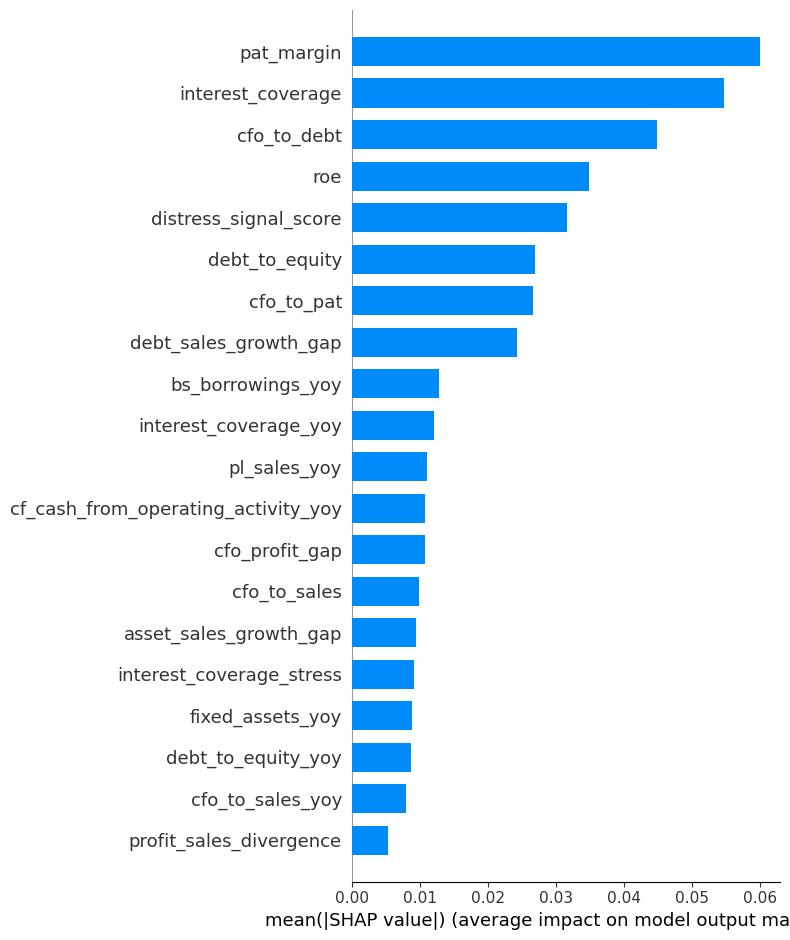

In [61]:
shap.summary_plot(
    shap_values_distress,
    X_imputed_df,
    plot_type="bar"
)

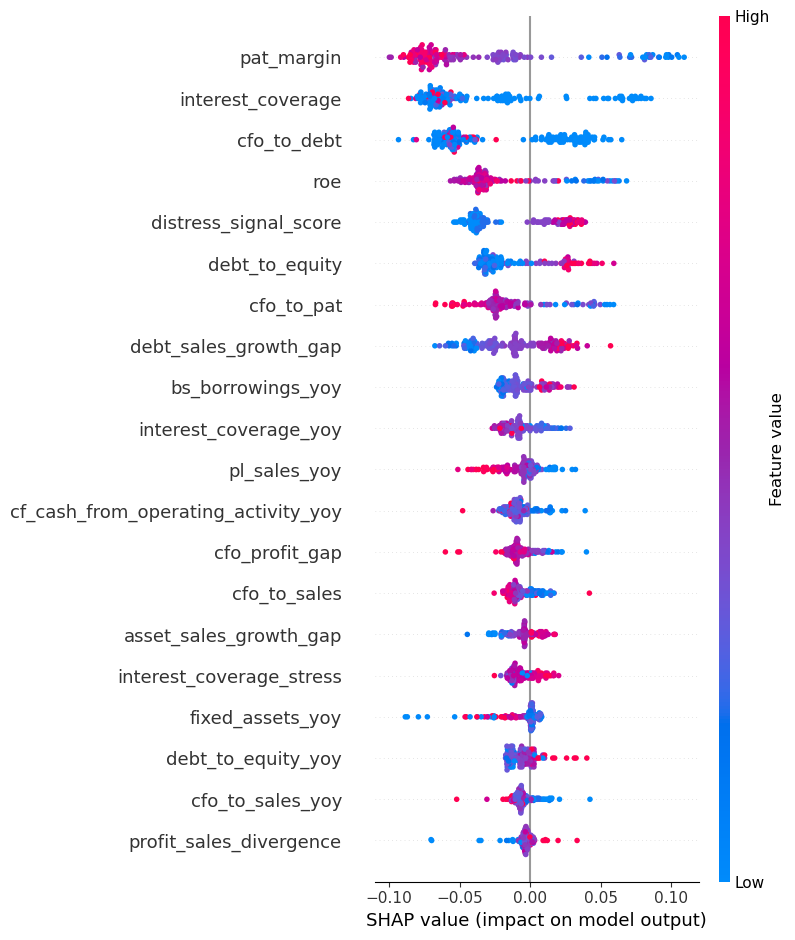

In [62]:
shap.summary_plot(
    shap_values_distress,
    X_imputed_df
)

In [63]:
shap_importance = pd.DataFrame({
    "Feature": usable_features,
    "Mean_ABS_SHAP": np.abs(shap_values_distress).mean(axis=0)
}).sort_values("Mean_ABS_SHAP", ascending=False)

shap_importance.head(20)

,Feature,Mean_ABS_SHAP
1,pat_margin,0.059937
6,interest_coverage,0.054707
3,cfo_to_debt,0.044922
5,roe,0.034923
22,distress_signal_score,0.031685
0,debt_to_equity,0.026896
4,cfo_to_pat,0.026609
16,debt_sales_growth_gap,0.024317
9,bs_borrowings_yoy,0.012841
13,interest_coverage_yoy,0.012022


In [64]:
import numpy as np
import pandas as pd

# Rename technical features into readable business language
feature_labels = {
    "debt_sales_growth_gap": "Debt growing faster than sales",
    "capex_cfo_stress": "Capex expansion despite weakening operating cash flow",
    "cfo_profit_gap": "Cash flow not supporting reported profits",
    "cost_sales_pressure": "Costs rising faster than sales",
    "interest_coverage_stress": "Deteriorating interest coverage",
    "asset_sales_growth_gap": "Asset expansion not matched by sales growth",
    "inventory_sales_stress": "Inventory build-up compared with sales",
    "receivable_sales_stress": "Receivables rising faster than sales",
    "contingent_liability_stress": "Increase in contingent liability burden",
    "distress_signal_score": "Multiple financial red flags",
    "debt_to_equity": "High debt compared with net worth",
    "pat_margin": "Profit margin weakness",
    "cfo_to_sales": "Weak operating cash generation",
    "cfo_to_debt": "Weak cash flow coverage of debt",
    "cfo_to_pat": "Earnings quality weakness",
    "interest_coverage": "Debt servicing capacity",
    "pl_sales_yoy": "Sales growth trend",
    "pl_net_profit_yoy": "Profit growth trend",
    "bs_borrowings_yoy": "Borrowings growth trend",
    "cf_cash_from_operating_activity_yoy": "Operating cash flow trend"
}

def plain_feature_name(feature):
    return feature_labels.get(feature, feature.replace("_", " ").title())


def explain_shap_plain_english(row_number, top_n=10):
    company = data.iloc[row_number]["company"]
    fy = data.iloc[row_number]["fy"]
    actual = data.iloc[row_number]["distress_next_year"]
    probability = data.iloc[row_number]["predicted_distress_probability"]

    row_explanation = pd.DataFrame({
        "Feature": usable_features,
        "Business_Meaning": [plain_feature_name(f) for f in usable_features],
        "Feature_Value": X_imputed_df.iloc[row_number].values,
        "SHAP_Value": shap_values_distress[row_number]
    })

    row_explanation["Direction"] = np.where(
        row_explanation["SHAP_Value"] > 0,
        "Increases distress risk",
        "Reduces distress risk"
    )

    row_explanation["Abs_SHAP"] = row_explanation["SHAP_Value"].abs()

    row_explanation = row_explanation.sort_values(
        "Abs_SHAP",
        ascending=False
    ).head(top_n)

    print("="*80)
    print("PLAIN-ENGLISH SHAP RISK EXPLANATION")
    print("="*80)
    print(f"Company: {company}")
    print(f"Financial Year: {fy}")
    print(f"Predicted distress probability: {probability:.1%}")
    print(f"Actual next-year distress label: {int(actual)}")
    print()

    print("Main reasons increasing distress risk:")
    increasing = row_explanation[row_explanation["SHAP_Value"] > 0]

    if len(increasing) == 0:
        print("- No major factors increased risk.")
    else:
        for _, row in increasing.iterrows():
            print(
                f"- {row['Business_Meaning']} "
                f"(value: {row['Feature_Value']:.2f}) increased the predicted distress risk."
            )

    print()
    print("Main reasons reducing distress risk:")
    reducing = row_explanation[row_explanation["SHAP_Value"] < 0]

    if len(reducing) == 0:
        print("- No major factors reduced risk.")
    else:
        for _, row in reducing.iterrows():
            print(
                f"- {row['Business_Meaning']} "
                f"(value: {row['Feature_Value']:.2f}) reduced the predicted distress risk."
            )

    return row_explanation

In [65]:
# Make sure risk probability is already added
data["predicted_distress_probability"] = rf_shap.predict_proba(X_imputed_df)[:, 1]

# Pick highest-risk company-year
highest_risk_row = data["predicted_distress_probability"].idxmax()

# Convert dataframe index to row position
row_number = data.index.get_loc(highest_risk_row)

explanation_table = explain_shap_plain_english(row_number, top_n=10)

explanation_table

PLAIN-ENGLISH SHAP RISK EXPLANATION
Company: G S Auto Intl
Financial Year: 2017
Predicted distress probability: 93.4%
Actual next-year distress label: 1

Main reasons increasing distress risk:
- Profit margin weakness (value: -0.05) increased the predicted distress risk.
- Debt servicing capacity (value: -0.74) increased the predicted distress risk.
- Roe (value: -0.16) increased the predicted distress risk.
- Earnings quality weakness (value: -1.81) increased the predicted distress risk.
- Weak cash flow coverage of debt (value: 0.24) increased the predicted distress risk.
- Multiple financial red flags (value: 4.00) increased the predicted distress risk.
- High debt compared with net worth (value: 1.20) increased the predicted distress risk.
- Debt growing faster than sales (value: 0.31) increased the predicted distress risk.
- Interest Coverage Yoy (value: -2.35) increased the predicted distress risk.
- Sales growth trend (value: -0.25) increased the predicted distress risk.

Main r

,Feature,Business_Meaning,Feature_Value,SHAP_Value,Direction,Abs_SHAP
1,pat_margin,Profit margin weakness,-0.050575,0.082545,Increases distress risk,0.082545
6,interest_coverage,Debt servicing capacity,-0.741697,0.070372,Increases distress risk,0.070372
5,roe,Roe,-0.157597,0.045532,Increases distress risk,0.045532
4,cfo_to_pat,Earnings quality weakness,-1.806838,0.044999,Increases distress risk,0.044999
3,cfo_to_debt,Weak cash flow coverage of debt,0.236624,0.031490,Increases distress risk,0.031490
22,distress_signal_score,Multiple financial red flags,4.000000,0.027383,Increases distress risk,0.027383
0,debt_to_equity,High debt compared with net worth,1.203394,0.024991,Increases distress risk,0.024991
16,debt_sales_growth_gap,Debt growing faster than sales,0.307490,0.017929,Increases distress risk,0.017929
13,interest_coverage_yoy,Interest Coverage Yoy,-2.347690,0.017144,Increases distress risk,0.017144
7,pl_sales_yoy,Sales growth trend,-0.248457,0.015176,Increases distress risk,0.015176


In [67]:
def trend_word(value, threshold=0.03):
    if pd.isna(value):
        return "not clearly available"
    elif value > threshold:
        return "increasing"
    elif value < -threshold:
        return "declining"
    else:
        return "stable"


def pct_text(value):
    if pd.isna(value):
        return "not available"
    return f"{value:.1%}"


def get_company_history(company, fy, years_back=3):
    hist = master[
        (master["company"] == company) &
        (master["fy"] <= fy) &
        (master["fy"] >= fy - years_back)
    ].sort_values("fy")

    return hist


def multi_year_financial_narrative(row_number, top_n=8):

    company = data.iloc[row_number]["company"]
    fy = data.iloc[row_number]["fy"]
    probability = data.iloc[row_number]["predicted_distress_probability"]

    hist = get_company_history(company, fy, years_back=3)

    # Latest row
    latest = hist.iloc[-1]

    sales_trend = latest.get("pl_sales_3yr_change", np.nan)
    profit_trend = latest.get("pl_net_profit_3yr_change", np.nan)
    debt_trend = latest.get("bs_borrowings_3yr_change", np.nan)
    cfo_trend = latest.get("cf_cash_from_operating_activity_3yr_change", np.nan)
    margin_trend = latest.get("pat_margin_3yr_change", np.nan)
    interest_trend = latest.get("interest_coverage_3yr_change", np.nan)

    row_shap = pd.DataFrame({
        "Feature": usable_features,
        "SHAP_Value": shap_values_distress[row_number]
    })

    row_shap["Abs_SHAP"] = row_shap["SHAP_Value"].abs()
    row_shap = row_shap.sort_values("Abs_SHAP", ascending=False).head(top_n)

    risk_features = row_shap[row_shap["SHAP_Value"] > 0]["Feature"].tolist()
    reducing_features = row_shap[row_shap["SHAP_Value"] < 0]["Feature"].tolist()

    narrative = []

    if probability >= 0.70:
        opening = f"{company} for FY{int(fy)} is classified as HIGH distress risk with a predicted probability of {probability:.1%}."
    elif probability >= 0.40:
        opening = f"{company} for FY{int(fy)} is classified as MEDIUM distress risk with a predicted probability of {probability:.1%}."
    else:
        opening = f"{company} for FY{int(fy)} is classified as LOW distress risk with a predicted probability of {probability:.1%}."

    narrative.append(opening)

    # Core multi-year pattern
    pattern = (
        f"Over the recent multi-year period, sales were {trend_word(sales_trend)}, "
        f"profits were {trend_word(profit_trend)}, borrowings were {trend_word(debt_trend)}, "
        f"and operating cash flows were {trend_word(cfo_trend)}."
    )
    narrative.append(pattern)

    # Specific distress logic
    if sales_trend > 0 and profit_trend < 0 and debt_trend > 0:
        narrative.append(
            "This is a distress signal because the company is growing sales but not converting that growth into profits, while borrowings are also increasing."
        )

    if profit_trend < 0 and cfo_trend < 0:
        narrative.append(
            "Both profitability and operating cash generation are weakening, indicating deterioration in the underlying financial quality."
        )

    if debt_trend > 0 and sales_trend <= debt_trend:
        narrative.append(
            "Borrowings have grown faster than or broadly in excess of sales growth, suggesting leverage-led growth rather than self-funded operational improvement."
        )

    if margin_trend < 0:
        narrative.append(
            "Profit margins have compressed over the multi-year period, indicating that cost increases or operating inefficiencies may be absorbing revenue growth."
        )

    if interest_trend < 0:
        narrative.append(
            "Interest coverage has deteriorated, indicating weakening ability to service debt from operating earnings."
        )

    # SHAP-linked reason
    shap_reason_map = {
        "debt_sales_growth_gap": "The model placed weight on the gap between borrowing growth and sales growth.",
        "capex_cfo_stress": "The model identified expansion or capex pressure despite weaker operating cash flows.",
        "cfo_profit_gap": "The model identified a mismatch between profits and cash flows.",
        "cost_sales_pressure": "The model identified cost pressure relative to sales growth.",
        "interest_coverage_stress": "The model identified weakening debt servicing capacity.",
        "distress_signal_score": "The model identified multiple simultaneous financial red flags.",
        "profit_sales_divergence": "The model identified that profit performance was not keeping pace with sales.",
        "asset_sales_growth_gap": "The model identified asset expansion not supported by proportionate sales growth."
    }

    shap_points = [
        shap_reason_map[f] for f in risk_features if f in shap_reason_map
    ]

    if shap_points:
        narrative.append("The SHAP explanation supports this assessment because " + " ".join(shap_points))

    return " ".join(narrative)

In [68]:
highest_risk_index = data["predicted_distress_probability"].idxmax()
row_number = data.index.get_loc(highest_risk_index)

print(multi_year_financial_narrative(row_number))

G S Auto Intl for FY2017 is classified as HIGH distress risk with a predicted probability of 93.4%. Over the recent multi-year period, sales were not clearly available, profits were not clearly available, borrowings were not clearly available, and operating cash flows were not clearly available. The SHAP explanation supports this assessment because The model identified multiple simultaneous financial red flags. The model placed weight on the gap between borrowing growth and sales growth.


In [70]:
def find_available_col(df, possible_cols):
    for col in possible_cols:
        if col in df.columns:
            return col
    return None


sales_col = find_available_col(master, [
    "pl_sales",
    "pl_revenue",
    "pl_sales_plus",
    "pl_revenue_from_operations"
])

profit_col = find_available_col(master, [
    "pl_net_profit",
    "pl_profit_after_tax",
    "pl_pat"
])

debt_col = find_available_col(master, [
    "bs_borrowings",
    "bs_total_borrowings",
    "bs_debt"
])

cfo_col = find_available_col(master, [
    "cf_cash_from_operating_activity",
    "cf_cash_from_operating_activities",
    "cf_operating_cash_flow"
])

interest_col = find_available_col(master, [
    "interest_coverage",
    "pl_interest_coverage"
])

margin_col = find_available_col(master, [
    "pat_margin",
    "pl_pat_margin"
])

print("Columns detected:")
print("Sales:", sales_col)
print("Profit:", profit_col)
print("Debt:", debt_col)
print("CFO:", cfo_col)
print("Interest coverage:", interest_col)
print("Margin:", margin_col)

Columns detected:
Sales: pl_sales
Profit: pl_net_profit
Debt: bs_borrowings
CFO: cf_cash_from_operating_activity
Interest coverage: interest_coverage
Margin: pat_margin


In [71]:
def compute_trend_from_history(hist, col):
    if col is None or col not in hist.columns:
        return np.nan

    s = hist[["fy", col]].dropna().sort_values("fy")

    if len(s) < 2:
        return np.nan

    first = s[col].iloc[0]
    last = s[col].iloc[-1]

    if pd.isna(first) or pd.isna(last):
        return np.nan

    if first == 0:
        return np.nan

    return (last - first) / abs(first)


def trend_word(value, threshold=0.05):
    if pd.isna(value):
        return "not clearly available"
    elif value > threshold:
        return "increasing"
    elif value < -threshold:
        return "declining"
    else:
        return "stable"


def format_trend(value):
    if pd.isna(value):
        return "not available"
    return f"{value:.1%}"

In [72]:
def multi_year_financial_narrative(row_number, years_back=3, top_n=8):

    company = data.iloc[row_number]["company"]
    fy = int(data.iloc[row_number]["fy"])
    probability = data.iloc[row_number]["predicted_distress_probability"]

    hist = master[
        (master["company"] == company) &
        (master["fy"] <= fy) &
        (master["fy"] >= fy - years_back)
    ].sort_values("fy")

    sales_trend = compute_trend_from_history(hist, sales_col)
    profit_trend = compute_trend_from_history(hist, profit_col)
    debt_trend = compute_trend_from_history(hist, debt_col)
    cfo_trend = compute_trend_from_history(hist, cfo_col)
    interest_trend = compute_trend_from_history(hist, interest_col)
    margin_trend = compute_trend_from_history(hist, margin_col)

    row_shap = pd.DataFrame({
        "Feature": usable_features,
        "SHAP_Value": shap_values_distress[row_number]
    })

    row_shap["Abs_SHAP"] = row_shap["SHAP_Value"].abs()
    row_shap = row_shap.sort_values("Abs_SHAP", ascending=False).head(top_n)

    risk_features = row_shap[row_shap["SHAP_Value"] > 0]["Feature"].tolist()

    if probability >= 0.70:
        risk_level = "HIGH"
    elif probability >= 0.40:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    narrative = []

    narrative.append(
        f"{company} for FY{fy} is classified as {risk_level} distress risk "
        f"with a predicted probability of {probability:.1%}."
    )

    narrative.append(
        f"Over the recent {years_back}-year period, sales were {trend_word(sales_trend)} "
        f"({format_trend(sales_trend)}), profits were {trend_word(profit_trend)} "
        f"({format_trend(profit_trend)}), borrowings were {trend_word(debt_trend)} "
        f"({format_trend(debt_trend)}), and operating cash flows were "
        f"{trend_word(cfo_trend)} ({format_trend(cfo_trend)})."
    )

    if pd.notna(sales_trend) and pd.notna(profit_trend) and pd.notna(debt_trend):
        if sales_trend > 0 and profit_trend < 0 and debt_trend > 0:
            narrative.append(
                "This indicates a stressed growth pattern: sales increased, but profits declined while borrowings increased."
            )

        elif sales_trend < 0 and profit_trend < 0 and debt_trend > 0:
            narrative.append(
                "This indicates a worsening distress pattern: sales and profits declined while borrowings increased."
            )

        elif sales_trend > 0 and profit_trend < 0:
            narrative.append(
                "This indicates weak conversion of revenue growth into profitability."
            )

    if pd.notna(profit_trend) and pd.notna(cfo_trend):
        if profit_trend < 0 and cfo_trend < 0:
            narrative.append(
                "Both profits and operating cash flows weakened, suggesting deterioration in financial quality."
            )

        elif profit_trend > 0 and cfo_trend < 0:
            narrative.append(
                "Profits improved but operating cash flows declined, indicating possible earnings quality concerns."
            )

    if pd.notna(debt_trend) and pd.notna(sales_trend):
        if debt_trend > sales_trend:
            narrative.append(
                "Borrowings grew faster than sales, suggesting that growth may be increasingly leverage-driven."
            )

    if pd.notna(margin_trend) and margin_trend < 0:
        narrative.append(
            "Profit margins compressed over the period, indicating rising cost pressure or weaker operating efficiency."
        )

    if pd.notna(interest_trend) and interest_trend < 0:
        narrative.append(
            "Interest coverage deteriorated, showing weakening ability to service debt."
        )

    shap_reason_map = {
        "debt_sales_growth_gap": "SHAP also identified borrowing growth relative to sales as a key risk driver.",
        "capex_cfo_stress": "SHAP also identified capex or expansion pressure despite weaker operating cash flow.",
        "cfo_profit_gap": "SHAP also identified a mismatch between profits and operating cash flows.",
        "cost_sales_pressure": "SHAP also identified cost pressure relative to sales.",
        "interest_coverage_stress": "SHAP also identified weakening debt servicing capacity.",
        "distress_signal_score": "SHAP also identified multiple simultaneous financial red flags.",
        "profit_sales_divergence": "SHAP also identified that profit performance did not keep pace with sales.",
        "asset_sales_growth_gap": "SHAP also identified asset expansion not supported by proportionate sales growth."
    }

    shap_points = [
        shap_reason_map[f] for f in risk_features if f in shap_reason_map
    ]

    if shap_points:
        narrative.append(" ".join(shap_points[:3]))

    return " ".join(narrative)

In [73]:
highest_risk_index = data["predicted_distress_probability"].idxmax()
row_number = data.index.get_loc(highest_risk_index)

print(multi_year_financial_narrative(row_number, years_back=3))

G S Auto Intl for FY2017 is classified as HIGH distress risk with a predicted probability of 93.4%. Over the recent 3-year period, sales were declining (-24.8%), profits were declining (-1260.5%), borrowings were increasing (5.9%), and operating cash flows were declining (-22.4%). This indicates a worsening distress pattern: sales and profits declined while borrowings increased. Both profits and operating cash flows weakened, suggesting deterioration in financial quality. Borrowings grew faster than sales, suggesting that growth may be increasingly leverage-driven. Profit margins compressed over the period, indicating rising cost pressure or weaker operating efficiency. Interest coverage deteriorated, showing weakening ability to service debt. SHAP also identified multiple simultaneous financial red flags. SHAP also identified borrowing growth relative to sales as a key risk driver.


In [74]:
def generate_latest_company_explanation(company_name, years_back=3):

    company_rows = data[
        data["company"].str.contains(company_name, case=False, na=False)
    ].copy()

    if company_rows.empty:
        print("No matching company found.")
        return None

    # Select latest available financial year
    latest_fy = company_rows["fy"].max()

    company_rows = company_rows[company_rows["fy"] == latest_fy]

    selected_index = company_rows.index[0]
    row_number = data.index.get_loc(selected_index)

    explanation = multi_year_financial_narrative(
        row_number,
        years_back=years_back
    )

    print(explanation)

    return explanation

In [75]:
generate_latest_company_explanation("G S Auto", years_back=3)

G S Auto Intl for FY2024 is classified as LOW distress risk with a predicted probability of 18.6%. Over the recent 3-year period, sales were increasing (98.2%), profits were increasing (118.2%), borrowings were stable (-2.1%), and operating cash flows were increasing (1028.1%).


'G S Auto Intl for FY2024 is classified as LOW distress risk with a predicted probability of 18.6%. Over the recent 3-year period, sales were increasing (98.2%), profits were increasing (118.2%), borrowings were stable (-2.1%), and operating cash flows were increasing (1028.1%).'

In [76]:
generate_latest_company_explanation("Akar Auto Indust", years_back=3)

Akar Auto Indust for FY2024 is classified as LOW distress risk with a predicted probability of 37.0%. Over the recent 3-year period, sales were increasing (99.3%), profits were increasing (293.3%), borrowings were increasing (5.2%), and operating cash flows were increasing (3864.0%). SHAP also identified multiple simultaneous financial red flags.


'Akar Auto Indust for FY2024 is classified as LOW distress risk with a predicted probability of 37.0%. Over the recent 3-year period, sales were increasing (99.3%), profits were increasing (293.3%), borrowings were increasing (5.2%), and operating cash flows were increasing (3864.0%). SHAP also identified multiple simultaneous financial red flags.'